In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format = lambda x: ('%.12f' % x).rstrip('0').rstrip('.')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))

# библиотеки визуализации:
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from datetime import datetime



In [2]:
PREPROCESSING_DIR = '/home/alorozhkov/jup/dashbords/dash_1/preprocessing'

In [3]:
customers = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/customers.csv')
items = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/order_items.csv') 
payments = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/order_payments.csv') 
orders = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/orders.csv') 
products = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/products.csv')
categories = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/product_category_name_translation.csv') 
sellers = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/sellers.csv')
geo = pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/geolocation.csv')
reviews =  pd.read_csv('/home/alorozhkov/jup/dashbords/dash_1/data/order_reviews.csv')

# EDA + Data Cleaning

In [4]:
# Джойню таблицы:
data = orders.merge(payments, how = 'inner', on = 'order_id') # заказы с платежами
data = data.merge(items, how = 'inner', on = 'order_id') # добавляю товары 
data = data.merge(products, how = 'inner', on = 'product_id') # инф о продуктах
data = data.merge(categories, how = 'inner', on = 'product_category_name') # категории продуктов
data = data.merge(customers, how = 'inner', on = 'customer_id') # инф о покупателях
data = data.merge(sellers, how ='inner', on = 'seller_id') # инф о продавцах
data = data.merge(reviews, how = 'inner', on = 'order_id') # отзывы

In [5]:
# Оставляю только необходимые столбцы для дальнейшей работы
columns_to_drop = ['payment_sequential', 'payment_installments', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'review_comment_title',
                  'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_zip_code_prefix', 'seller_zip_code_prefix', 'product_category_name', 'customer_id']
df = data.drop(columns=columns_to_drop)

In [6]:
# Преобразую поля с датами к формату datetime:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [7]:
# Создаю временные признаки для дальнейшего анализа в динамике (месяц год/ год / месяц)
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_month_num'] = df['order_purchase_timestamp'].dt.month

In [8]:
# смотрю пропуски
missing_df = pd.DataFrame({
    'поле': df.columns,
    'кол-во nan значений': df.isnull().sum(),
    '% nan': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('кол-во nan значений', ascending=False)

missing_df = missing_df.reset_index(drop=True)

display(missing_df)

,поле,кол-во nan значений,% nan
0,order_delivered_customer_date,2400,2.08
1,order_delivered_carrier_date,1195,1.03
2,order_approved_at,14,0.01
3,order_id,0,0.00
4,order_status,0,0.00
5,order_purchase_timestamp,0,0.00
6,order_estimated_delivery_date,0,0.00
7,payment_type,0,0.00
8,payment_value,0,0.00
9,order_item_id,0,0.00


In [9]:
# смотрю на полные дубликаты строк:
duplicate_count = df.duplicated().sum()
duplicate_count

660

In [10]:
#  все дубликаты (keep=False)
all_duplicates = df[df.duplicated(keep=False)]
# сортирую для наглядности
all_duplicates_sorted = all_duplicates.sort_values(by=all_duplicates.columns.tolist())
print(f"Исходный размер: {df.shape}")
print(f"Количество дублированных строк: {df.duplicated().sum()}")

Исходный размер: (115609, 26)
Количество дублированных строк: 660


In [11]:
# Удаляю дубликаты, оставляя первое вхождение
df_clean = df.drop_duplicates(keep='first')
print(f"Размер после удаления дублей: {df_clean.shape}")

Размер после удаления дублей: (114949, 26)


In [12]:
# Смотрю уникальные статусы заказов
print(df_clean['order_status'].value_counts())

order_status
delivered      112564
shipped          1132
canceled          535
invoiced          357
processing        351
unavailable         7
approved            3
Name: count, dtype: int64


In [13]:
# Смотрю за какой период  данные:
df_unique = df_clean['purchase_month'].drop_duplicates().sort_values().to_frame(name='unique_dates')
print(df_unique)

       unique_dates
12483       2016-09
2691        2016-10
64803       2016-12
2105        2017-01
81          2017-02
102         2017-03
70          2017-04
75          2017-05
79          2017-06
19          2017-07
3           2017-08
8           2017-09
0           2017-10
12          2017-11
108         2017-12
112         2018-01
125         2018-02
114         2018-03
127         2018-04
152         2018-05
128         2018-06
166         2018-07
154         2018-08
115028      2018-09


! Нет 2016-11 месяца....

# Расчет метрик в разрезе заказа

In [14]:
# Кол-во селлеров на один заказ:
diff_sellers_per_order = df_clean.groupby('order_id')['seller_id'].nunique()
diff_sellers_per_order = diff_sellers_per_order[diff_sellers_per_order > 1].reset_index()
print(f"Всего заказов: {df_clean['order_id'].nunique():,} шт")
print(f"Заказов с несколькими селлерами: {len(diff_sellers_per_order):,} шт")
print(f"Доля заказов с несколькими селлерами: {len(diff_sellers_per_order) / df_clean['order_id'].nunique() * 100:.2f}%")

Всего заказов: 96,516 шт
Заказов с несколькими селлерами: 1,236 шт
Доля заказов с несколькими селлерами: 1.28%


Вывод - в 1.31% заказов участвует больше одного селлера, что создаёт сложности при расчёте метрик:

- Выручка — payment_value относится ко всему заказу, непонятно, как её делить между продавцами.

- Просрочка — если один продавец задержал свой товар, клиент всё равно может поставить низкую оценку, из-за чего пострадает и добросовестный продавец.

- Оценка — одна на весь заказ, нельзя привязать к конкретному продавцу.

Cчитаю лучшим выходом в данной ситуации работать только с 98.69% данных с 1 селлером на заказ, так как это репрезентативно + будут чистые метрики без искажений.

Заказы с несколькими селлерами сохраняю в таблицу diff_sellers_per_order для дальнейшего анализа:

In [15]:
# сохранение таблицы diff_sellers_per_order:
diff_sellers_per_order.to_csv(f'{PREPROCESSING_DIR}/diff_sellers_per_order.csv', index=False)
print(f'Сохранено в: {PREPROCESSING_DIR}/diff_sellers_per_order.csv')

Сохранено в: /home/alorozhkov/jup/dashbords/dash_1/preprocessing/diff_sellers_per_order.csv


In [16]:
# заказы с одним селлером:
orders_with_one_seller = df_clean.groupby('order_id')['seller_id'].nunique()
orders_one = orders_with_one_seller[orders_with_one_seller == 1].index

In [17]:
df_new = df_clean[df_clean['order_id'].isin(orders_one)].copy()

In [18]:
print(f"Исходное число заказов: {df_clean['order_id'].nunique():,}")
print(f"После фильтрации: {df_new['order_id'].nunique():,}")
print(f"Оставлено строк: {len(df_new):,} из {len(df_clean):,}")

Исходное число заказов: 96,516
После фильтрации: 95,280
Оставлено строк: 111,744 из 114,949


Необходимые метрики на уровне заказа:
- processing_time - время от оплыты заказа до передачи перевозчику
- is_canceled – статус заказа «canceled»
- review_score – оценка из отзывов (1–5)

In [19]:
df_orders = df_new.copy()

In [20]:
# работаю только со статусами заказа- достален /отменен / нет на складе:
#df_orders = df_new[df_new['order_status'].isin(['delivered', 'canceled', 'unavailable'])].copy()

Добавляю метрику - время обработки заказа селлером(сборка, транспортировка до ТК) в днях с точностью до секунд -  'processing_days'
    
Данная метрика вычисляется путем разницы между  'отдана перевозчику' и 'дата оплаты заказа покупателем' 

In [21]:
# Время обработки продавцом (от покупки до передачи перевозчику) в днях с часами:
df_orders['processing_days'] = (df_orders['order_delivered_carrier_date'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 86400 

In [22]:
# Задержка доставки:
#df_orders['is_delayed'] = np.where((df_orders['order_status'] == 'delivere') & (df_orders['order_delivered_customer_date'] > df_orders['order_estimated_delivery_date']), 1,0)

Ввожу флаг отмены или недоступности заказа чтобы посчитать упущенную выручку далее:

In [23]:
df_orders['is_canceled'] = (df_orders['order_status'].isin(['canceled', 'unavailable'])).astype(int)

In [24]:
s = df_orders[(df_orders['is_canceled'] == 1) & (df_orders['order_status'] == 'delivered')]
s

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score,purchase_month,purchase_year,purchase_month_num,processing_days,is_canceled


Считаю упущенную выручку - сколько бизнес теряет денег на уже проданных но отсутсвующих товарах по факту + на отмененных заказах селлеров:

In [25]:
# Упущенная выручка 
#lost_revenue = df_orders[df_orders['is_canceled'] == 1]['payment_value'].sum()
#print(f"Упущенная выручка из-за отмен или отсутсвия товара: {lost_revenue:,.2f}")

In [26]:
lost_rev= df_orders[df_orders['is_canceled'] == 1][['order_id','payment_value']].drop_duplicates('order_id')['payment_value'].sum()
lost_rev

100357.59999999999

Теперь создам новый столбец с упущенной выручкой по каждому продавцу

In [27]:
# сначала создам столбец payment_value для отмененных заказов
df_orders['payment_if_canceled'] = df_orders['is_canceled'] * df_orders['payment_value']
# теперь группирую по селлеру и суммирую, затем трансформирую на все строки по этому селлеру
df_orders['lost_revenue_per_seller'] = df_orders.groupby('seller_id')['payment_if_canceled'].transform('sum') 

In [28]:
df_orders[(df_orders['seller_id'] == '620c87c171fb2a6dd6e8bb4dec959fc6') & (df_orders['is_canceled'] == 1)]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score,purchase_month,purchase_year,purchase_month_num,processing_days,is_canceled,payment_if_canceled,lost_revenue_per_seller
44132,770d331c84e5b214bd9dc70a10b829d0,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29,credit_card,263.93,1,eba7488e1c67729f045ab43fac426f2e,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-11 15:07:11,249.90,14.03,perfumery,59a7bb642795ddc85534fbd5f7360334,rio de janeiro,RJ,petropolis,RJ,9399c464901dcf9d6a40e6dde8ebdf59,1,2016-10,2016,10,4.01,1,263.93,1 375.15
44137,1a47da1d66c70489c8e35fe2b5433ab7,unavailable,2016-10-07 18:16:31,2016-10-07 18:53:48,NaT,NaT,2016-12-07,credit_card,270.75,1,eba7488e1c67729f045ab43fac426f2e,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-11 18:53:48,249.90,20.85,perfumery,b18b6d40c3c5510727e0f22b568d3e1f,porto alegre,RS,petropolis,RJ,35fa5e7e3020710116f5ff6df38b2a59,5,2016-10,2016,10,NaN,1,270.75,1 375.15
44150,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30,credit_card,140.22,1,473795a355d29305c3ea6b156833adf5,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-13 13:36:59,59.90,0.48,perfumery,2f96790fba243100730c8d1185dd2f25,sao paulo,SP,petropolis,RJ,28112c56c882286e0b235173e84c5370,5,2016-10,2016,10,4.53,1,140.22,1 375.15
44151,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30,credit_card,140.22,2,7cd29da0653abeb444703cc5a957f479,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-13 13:36:59,49.90,29.94,health_beauty,2f96790fba243100730c8d1185dd2f25,sao paulo,SP,petropolis,RJ,28112c56c882286e0b235173e84c5370,5,2016-10,2016,10,4.53,1,140.22,1 375.15
44201,6cf51ab464bdd9f7b282f5fe72391383,canceled,2018-02-27 22:43:39,2018-02-27 22:55:52,2018-02-28 20:07:53,NaT,2018-03-13,credit_card,64.17,1,473795a355d29305c3ea6b156833adf5,620c87c171fb2a6dd6e8bb4dec959fc6,2018-03-05 22:55:52,55.90,8.27,perfumery,eea6e74f086071ad4d5578a5e34c77b5,rio de janeiro,RJ,petropolis,RJ,7523fe749b1e18486735621a2f2e3c25,1,2018-02,2018,2,0.89,1,64.17,1 375.15
44451,4dd47e84e6b8ff4a63d0b8425e6d788e,unavailable,2016-10-06 23:49:18,2016-10-07 01:09:08,NaT,NaT,2016-11-24,credit_card,313.58,1,2aa489c905e1d41d8c716a6d6912d8c2,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-11 01:09:09,299.90,13.68,perfumery,e347a8d0bfec0255258cc913ed28d3a9,campos dos goytacazes,RJ,petropolis,RJ,deab3ad3f78fd4ef275d9788978b92c9,1,2016-10,2016,10,NaN,1,313.58,1 375.15
44546,b8752fc264f1692031237bb715061cc4,canceled,2018-02-22 16:58:06,2018-02-22 17:15:47,2018-02-23 20:49:02,NaT,2018-03-09,credit_card,68.17,1,b8a0d73b2a06e7910d9864dccdb0cda2,620c87c171fb2a6dd6e8bb4dec959fc6,2018-02-28 17:15:47,59.90,8.27,health_beauty,505fe88e18db61affa7c0f8adbeda4c2,sao joao de meriti,RJ,petropolis,RJ,c72c4e21a4510017a121321380d9d7e8,3,2018-02,2018,2,1.16,1,68.17,1 375.15
44690,847e04c1fabd29748790e74c1430c603,canceled,2018-08-06 20:05:00,2018-08-06 20:25:19,NaT,NaT,2018-08-13,voucher,45.34,1,662eb743b41155e398e7fdd5d4cf5a3a,620c87c171fb2a6dd6e8bb4dec959fc6,2018-08-09 20:25:19,39.90,9.21,health_beauty,8964628f0dd7ab0fe0751abedcbd317d,marica,RJ,petropolis,RJ,282f648dd1155e9f52d6a76b00f53227,1,2018-08,2018,8,NaN,1,45.34,1 375.15
44691,847e04c1fabd29748790e74c1430c603,canceled,2018-08-06 20:05:00,2018-08-06 20:25:19,NaT,NaT,2018-08-13,credit_card,3.77,1,662eb743b41155e398e7fdd5d4cf5a3a,620c87c171fb2a6dd6e8bb4dec959fc6,2018-08-09 20:25:19,39.90,9.21,health_beauty,8964628f0dd7ab0fe0751abedcbd317d,marica,RJ,petropolis,RJ,282f648dd1155e9f52d6a76b00f53227,1,2018-08,2018,8,NaN,1,3.77,1 375.15
44830,5d366aa

In [29]:
canceled_unique = df_orders[df_orders['is_canceled'] == 1][['order_id', 'seller_state', 'payment_value']].drop_duplicates('order_id')
lost_revenue_by_state = canceled_unique.groupby('seller_state')['payment_value'].sum().reset_index()
lost_revenue_by_state = lost_revenue_by_state.sort_values('payment_value', ascending=False)
lost_revenue_by_state

,seller_state,payment_value
10,SP,69 504.09
4,MG,10 261.64
9,SC,8 953.99
6,PR,5 235.69
7,RJ,4 180.94
8,RS,887.49
2,DF,727.96
0,BA,272.08
3,GO,179.44
1,CE,90.23


In [30]:
canceled_count = df_orders['is_canceled'].sum()
total_orders = len(df_orders)
share = canceled_count / total_orders
print(f"Всего заказов: {len(df_orders)}")
print(f"Отменённых: {df_orders['is_canceled'].sum()}")
print(f"Доля: {df_orders['is_canceled'].sum() / len(df_orders):.4%}")

Всего заказов: 111744
Отменённых: 540
Доля: 0.4832%


Вывод:
- Большинство заказов(98,7%) совершается с участием одного селлера на заказ
- Доля отмененных заказов по вине селлера крайне мала - всего 0,48% ---> Система резервирования товаров и выполнение заказов работают на высоком уровне. Проблема отмен/отсутствия товаров не является критической для бизнеса.
- Упущенная выручка от отмен – 148 318,78 реалов (почти 2 ляма рос).... 
- Географическая концентрация потерь - штат SP(Сан-Паулу) дает 63% всех убытков --->  Работу по снижению отмен имеет смысл начать с продавцов из штата SP (и в меньшей степени SC, PR, MG). Возможно, там выше доля мелких продавцов, которые не могут обеспечить реальное наличие товара.

### Вопросы
- почему отмененные заказы сконцентрированы практически в оном штате?
- упущенная выручка от отмен заказов  - это какая доля от общей выручки
- не понятно в каких деньгах измеряется
- необходимо проанализировать processing_days у отмененных товаров - возможно задержки обработки ведут к отмене заказа 
- сравнить долю отмен по категория товаров - возможно отмены только в отдельных категориях
- придумать санкции для продавцов с частыми отменами

### Анализ processing_days у отмененных товаров и не отмененных заказов:

In [31]:
canceled_processing = df_orders[df_orders['is_canceled'] == 1]['processing_days'].describe()
print(canceled_processing)

count   68.00
mean     3.60
std      5.43
min      0.37
25%      1.26
50%      2.22
75%      3.98
max     40.42
Name: processing_days, dtype: float64


In [32]:
df_orders['processing_days'] = df_orders['processing_days'].clip(lower=0)

In [33]:
not_canceled_processing = df_orders[df_orders['is_canceled'] == 0]['processing_days'].describe()
print(not_canceled_processing)

count   110 491.00
mean          3.31
std           3.61
min           0.00
25%           1.14
50%           2.25
75%           4.14
max         107.06
Name: processing_days, dtype: float64


Вывод - Статистически значимой разницы в processing_days между группами нет - средние значения почти одинаковы, медианы совпадают, распределения перекрываются...

Следовательно, для тех отменённых заказов, которые дошли до передачи перевозчику, задержка обработки не является причиной отмены. 

### Анализ времени обработки и времени подтверждения заказа 

In [34]:
df_orders['approval_days'] = (df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
display(df_orders.groupby('is_canceled')['approval_days'].describe())

,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,111 190.00,0.44,0.92,0.00,0.01,0.01,0.62,60.45
1,540.00,0.51,2.00,0.00,0.01,0.01,0.54,32.54


Анализ времени обработки (processing_days) и времени подтверждения (approval_days) показал, что отмены заказов не связаны с задержками на стороне продавца на этих этапах. 87% отмен происходит до передачи заказа перевозчику, причём большинство отмен подтверждаются так же быстро, как и доставленные. Основные причины отмен, вероятно, лежат в клиентском поведении или отсутствии товара. Рекомендовано внедрить автоматическое резервирование товара и провести опрос клиентов, отменивших заказы

### Сравним долю отмен по категориям товаров - скорре всего отмены только в определенных категориях (системные проблемы в категориях)

In [35]:
# Агрегация по категориям (без продавца)
category_cancel = df_orders.groupby('product_category_name_english').agg(
    total_orders = ('order_id', 'nunique'),
    canceled_orders = ('is_canceled', 'sum'),
    cancel_rate = ('is_canceled', 'mean')
).reset_index()

# Отсекаем категории с малым числом заказов (например, <30)
category_cancel = category_cancel[category_cancel['total_orders'] >= 30]

# Топ-20 категорий по доле отмен
top_categories = category_cancel.sort_values('cancel_rate', ascending=False).head(20)
print(top_categories)

              product_category_name_english  total_orders  canceled_orders  cancel_rate
25                             dvds_blu_ray            56                3         0.05
19                construction_tools_safety           160                5         0.03
21                 costruction_tools_garden           185                4         0.02
56                      musical_instruments           613               11         0.02
34                          fixed_telephony           212                4         0.01
8                    books_general_interest           506                7         0.01
51  kitchen_dining_laundry_garden_furniture           241                3         0.01
63                         small_appliances           620                7         0.01
16                           consoles_games          1040               10         0.01
69                                     toys          3807               34         0.01
49                              

В cancel_rate в категориях колеблются от 0,01 до 0,05 (1–5%). При этом total_orders многих категорий ~200–600, а отмен – 2–10 штук. Разница между 2% и 5% может быть случайной. Стоит:

добавить доверительные интервалы (например, по формуле Вильсона);

либо использовать beta-распределение для ранжирования;

либо просто отметить, что на уровне категорий значимых различий нет (все доли низкие).



 ### в каких категориях конкретный продавец часто отменяет заказы (проблемные связки «продавец → категория»)

In [36]:
# агрегирую на уровне селлер - категория:
seller_cat_agg = df_orders.groupby(['seller_id', 'product_category_name_english']).agg(
    orders_in_cat = ('order_id', 'nunique') >= 5,
    revenue_in_cat = ('payment_value', 'sum'),
    avg_processing_days_cat = ('processing_days', 'mean'),
    cancel_rate_cat = ('is_canceled', 'mean'),
    avg_review_cat = ('review_score', 'mean'),
    low_review_orders_cat = ('review_score', lambda x: (x <= 2).sum())
).reset_index()

seller_cat_agg = seller_cat_agg[seller_cat_agg['orders_in_cat'] >= 5] #чтобы выделить действительно проблемных продавцов с устойчивой высокой долей отмен.

TypeError: '>=' not supported between instances of 'tuple' and 'int'

In [ ]:
s = seller_cat_agg[seller_cat_agg['cancel_rate_cat'] > 0.00]
top = s.sort_values('cancel_rate_cat', ascending=False)
top.head(20)

### # Агрегация по продавцам

In [ ]:
# Создаём колонку: payment_value для доставленных, 0 для отменённых
df_orders['revenue_per_seller'] = df_orders['payment_value'] * (df_orders['is_canceled'] == 0)

In [ ]:
seller_agg = df_orders.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue_per_seller', 'sum'),   # только доставленные
    avg_processing_days=('processing_days', 'mean'),
    median_processing_days=('processing_days', 'median'),
    cancel_rate=('is_canceled', 'mean'),
    avg_review_score=('review_score', 'mean'),
    median_review_score=('review_score', 'median'),
    low_review_orders=('review_score', lambda x: (x <= 2).sum()),
    total_reviews=('review_score', 'count')
).reset_index()
seller_agg

### упущенная выручка от отмен заказов - это какая доля от общей выручки

total_revenue_all = df_orders[['order_id', 'payment_value']].drop_duplicates('order_id')['payment_value'].sum()
lost_share = lost_revenue / total_revenue_all

print(f"Общая выручка (все заказы): {total_revenue_all:,.2f}")
print(f"Упущенная выручка из-за отмен: {lost_revenue:,.2f}")
print(f"Доля упущенной выручки: {lost_share:.2%}")

### У селлера отправки всегда из одного штата или из нескольких?

In [ ]:
# У селлера отправки с одного штата или нет?
# - группирую по каждому селлеру и считаю кол-во уникальных штатов
seller_states = df_orders.groupby('seller_id')['seller_state'].nunique().reset_index(name='unique_states')
multi_state_sellers = seller_states[seller_states['unique_states'] > 1]
print(f"Количество селлеров с несколькими штатами: {len(multi_state_sellers)}")

### План

что сделать:
сформировать и проверить гипотезы на данных
доказательство причинно-следственных связей
оценить сценарии - что если?
рекомендации + система штрафов

Исправить дублирование payment_value во всех расчётах выручки.

Очистить данные от аномалий (отрицательные processing_days, слишком большие approval_days).

Добавить статистические тесты (t-test / Mann-Whitney, chi-square для категорий).


Провести временной анализ – графики отмен по месяцам, сезонность.

Исследовать корреляцию cancel_rate с review_score, payment_type, freight_value.

Подготовить дашборд

In [ ]:
# Гипотезы о причинах отмен заказов

In [ ]:
### Гипотезы об эффективности продавцов

In [ ]:
### Гипотезы о связи отзывов и отмен

In [ ]:
### Временные гипотезы

In [ ]:
### Географические гипотезы


In [ ]:
### Гипотезы о потерянной выручке

Необходимые метрики в разрезе продавца:
- Количество заказов
- доля просрочек
- средний processing time
- доля отмен
- средний review score
- суммарная выручка (sum(payment_value)) по продавцу

In [360]:
seller_agg = df_valid.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('payment_value', 'sum'),
    avg_processing_days=('processing_days', 'mean'),
    median_processing_days=('processing_days', 'median'),
    cancel_rate=('is_canceled', 'mean'),
    avg_review_score=('review_score', 'mean'),
    median_review_score=('review_score', 'median'),
    low_review_orders=('review_score', lambda x: (x <= 2).sum()),  # оценки 1-2
    total_reviews=('review_score', 'count')
).reset_index()

KeyError: "Column(s) ['is_delayed'] do not exist"

In [43]:
# У селлера отправки с одного штата или нет?
# Для проверки этой гипотезы - группирую по каждому селлеру и считаю кол-во уникальных штатов
seller_states = df_clean_1.groupby('seller_id')['seller_state'].nunique().reset_index(name='unique_states')
multi_state_sellers = seller_states[seller_states['unique_states'] > 1]
print(f"Количество селлеров с несколькими штатами: {len(multi_state_sellers)}")

Количество селлеров с несколькими штатами: 0


In [44]:
# Добавляю информацию о штате продавца
seller_state = df_valid.groupby('seller_id')['seller_state'].first().reset_index()
seller_agg = seller_agg.merge(seller_state, on='seller_id', how ='inner')

### анализ продавцов в разрезе селлер и категория товара

In [41]:
seller_agg.sample(2)

,seller_id,total_orders,total_revenue,avg_processing_days,median_processing_days,delayed_rate,cancel_rate,avg_review_score,median_review_score,low_review_orders,total_reviews,seller_state
1615,89bc797e2e29667aa035d4368f9b7f92,16,846.04,8.540048732943,4.676539351852,0.157894736842,0,3.894736842105,4,3,19,SP
1695,8fdca8e349553f99bc738833a62c8802,21,2016.17,2.347807539683,1.621128472222,0.035714285714,0,4.357142857143,5,2,28,SP


In [45]:
# У одного селлера товары из разных категорий?
seller_categories = df_clean_1.groupby('seller_id')['product_category_name_english'].nunique().reset_index(name='unique_categories')
multi_cat_sellers = seller_categories[seller_categories['unique_categories'] > 1]
print(f"Количество селлеров с несколькими категориями: {len(multi_cat_sellers)}")

Количество селлеров с несколькими категориями: 1286


In [46]:
if len(multi_cat_sellers) > 0:
    # Получить список категорий для каждого такого продавца
    seller_cat_details = df_clean_1.groupby('seller_id')['product_category_name_english'].unique().reset_index(name='categories')
    multi_details = seller_cat_details[seller_cat_details['seller_id'].isin(multi_cat_sellers['seller_id'])]
    print(multi_details.head(10))
else:
    print("Нет ни одного селлера, продающего товары из разных категорий.")

                           seller_id                                                                                                              categories
1   001cca7ae9ae17fb1caed9dfb1094831                                                                         [garden_tools, construction_tools_construction]
8   00ee68308b45bc5e2660cd833c3f81cc                                                                     [bed_bath_table, furniture_mattress_and_upholstery]
14  013900e863eace745d3ec7614cab5b1a                                                                                       [stationery, baby, fashion_shoes]
15  014c0679dd340a0e338872e7ec85666a                                         [garden_tools, kitchen_dining_laundry_garden_furniture, signaling_and_security]
20  01cf7e3d21494c41fb86034f2e714fa1  [housewares, bed_bath_table, baby, cool_stuff, air_conditioning, small_appliances, home_appliances, home_appliances_2]
22  01fd077212124329bac32490e8ef80d9           [garden_too

In [48]:
#  добавляю в df_clean_1 поля:
# processing_days (время от заказа до отправки перевозчику)
df_clean_1['processing_days'] = (df_clean_1['order_delivered_carrier_date'] - df_clean_1['order_purchase_timestamp']).dt.days

# is_delayed (доставка клиенту позже обещанной даты)
df_clean_1['is_delayed'] = (df_clean_1['order_delivered_customer_date'] > df_clean_1['order_estimated_delivery_date']).astype(int)

# is_canceled (статус заказа)
df_clean_1['is_canceled'] = (df_clean_1['order_status'] == 'canceled').astype(int)

In [49]:
# агрегирую на уровне селлер - категория:
seller_cat_agg = df_clean_1.groupby(['seller_id', 'product_category_name_english']).agg(
    orders_in_cat = ('order_id', 'nunique'),
    revenue_in_cat = ('payment_value', 'sum'),
    avg_processing_days_cat = ('processing_days', 'mean'),
    delayed_rate_cat = ('is_delayed', 'mean'),
    cancel_rate_cat = ('is_canceled', 'mean'),
    avg_review_cat = ('review_score', 'mean'),
    low_review_orders_cat = ('review_score', lambda x: (x <= 2).sum())
).reset_index()

На данном этапе возникает вопрос - а что есть эффективность для селлеров которые торгуют разными категориями товара, и например, по одной категории у селлера нет вообще задержек в отгрузках, а по другой есть?
Здесь нужно ввести некий критерий, который как раз и будет оценивать эффективность селлера.
    
Критерий можно рассчитать разными способами, например:
- считаем по каждой категории продавца долю просрочек  через разброс = максимальная доля по продавцу % - минимальная доля по продавцу % -  в результате получим  например 30 процентных пунктов 
- объединяем несколько метрик (просрочки, отмены, оценки) в одну формулу. Например, для каждой категории считаем «здоровье», а затем по селлеру — минимум или среднее.
- смотрим по упущенной выручке в проблемной категории

В нашем случаем выбираем следующий критерий неэффективности селлера:
селлер признается неэффективным, если в любой категории в которой он торговал с числом заказов >=5 выполняются условия delayed_rate > 0.25 ИЛИ cancel_rate > 0.10 ИЛИ avg_review < 3 

т.е. селлер будет считать неэффективным если провалиться хотя бы по одной из метрик:
- delay_rate
- cancel_rate
- avg_review

 Ведь клиенту всё равно, есть ли у продавца отмены, если ему пришла бракованная вещь. Клиентский опыт портится от любой из этих проблем по отдельности.


In [50]:
# Берём общую выручку селлера из seller_agg (или пересчитываем)
seller_total_revenue = seller_agg[['seller_id', 'total_revenue']]

In [51]:
seller_cat_agg = seller_cat_agg.merge(seller_total_revenue, on='seller_id', how='inner')

In [52]:
# добавляю флаг проблемной категории у селлера, с порогом по кол-ву заказов в рамках категории от 5 шт 
# Критерий: orders_in_cat >= 5 и (delayed_rate > 0.25 ИЛИ cancel_rate > 0.10 ИЛИ avg_review < 3)
seller_cat_agg['is_problematic'] = (
    (seller_cat_agg['orders_in_cat'] >= 5) &
    ((seller_cat_agg['delayed_rate_cat'] > 0.25) |
     (seller_cat_agg['cancel_rate_cat'] > 0.10) |
     (seller_cat_agg['avg_review_cat'] < 3))
)

# Проверим, сколько получилось проблемных категорий
print(f"Проблемных категорий (с заказами >=5): {seller_cat_agg['is_problematic'].sum()}")

Проблемных категорий (с заказами >=5): 211


In [53]:
# агрегирую до селлера - неэффективен, если есть хотя бы одна проблемная категория
# Для каждого селлера: есть ли хоть одна проблемная категория
seller_inefficient = seller_cat_agg.groupby('seller_id')['is_problematic'].any().reset_index()
seller_inefficient.columns = ['seller_id', 'is_inefficient']

In [54]:
# Добавим список проблемных категорий (опционально)
problem_cats = seller_cat_agg[seller_cat_agg['is_problematic']].groupby('seller_id')['product_category_name_english'].agg(list).reset_index()
problem_cats.columns = ['seller_id', 'problem_categories']

In [55]:
seller_inefficient = seller_inefficient.merge(problem_cats, on='seller_id', how='inner')

In [56]:
# объединяю с общей инф о селлере
# Берём нужные колонки из seller_agg
seller_info = seller_agg[['seller_id', 'total_orders', 'total_revenue', 'delayed_rate', 'cancel_rate', 'avg_review_score']]

In [57]:
# Сливаем
final_report = seller_inefficient.merge(seller_info, on='seller_id', how='left')

In [58]:
# Заполним NaN для тех, у кого нет проблемных категорий (problem_categories будет NaN)
final_report['problem_categories'] = final_report['problem_categories'].fillna('').apply(lambda x: x if isinstance(x, list) else [])

In [59]:
# Сортируем: сначала неэффективные, потом по выручке
final_report = final_report.sort_values(['is_inefficient', 'total_revenue'], ascending=[False, False])

In [60]:
print(f"Всего селлеров: {len(final_report)}")
print(f"Неэффективных селлеров (по критерию): {final_report['is_inefficient'].sum()}")
print("\nПервые 10 строк отчёта:")
display(final_report.head(10))

Всего селлеров: 193
Неэффективных селлеров (по критерию): 193

Первые 10 строк отчёта:


,seller_id,is_inefficient,problem_categories,total_orders,total_revenue,delayed_rate,cancel_rate,avg_review_score
102,7c67e1448b00f6e969d365cea6b010ab,True,"[furniture_living_room, sports_leisure]",967,505871.979999999981,0.093006993007,0,3.38951048951
56,4869f7a5dfa277a7dca6462dcf3b52b2,True,[consoles_games],1117,260121.649999999994,0.119863013699,0.000856164384,4.128424657534
98,77530e9772f57a62c906e1c21538ab82,True,[baby],312,82765.259999999995,0.114503816794,0,4.099236641221
136,b2ba3715d723d245138f291a6fe42594,True,[construction_tools_construction],325,60926.330000000002,0.080110497238,0.011049723757,4.190607734807
137,b33e7c55446eabf8fe1a42d037ac7d6d,True,[audio],149,48671.459999999999,0.129032258065,0,4.206451612903
182,f08a5b9dd6767129688d001acafc21e5,True,[computers_accessories],11,48401.480000000003,0.222222222222,0,3.444444444444
96,76d5af76d0271110f9af36c92573f765,True,[home_construction],127,43695.720000000001,0.080745341615,0,4.124223602484
38,2eb70248d66e0e3ef83659f71b244378,True,"[baby, computers_accessories, consoles_games, watches_gifts]",183,41633.599999999999,0.126903553299,0,2.827411167513
88,70a12e78e608ac31179aea7f8422044b,True,[sports_leisure],310,37687.979999999996,0.106194690265,0,3.808259587021
170,de23c3b98a88888289c6f5cc1209054a,True,[perfumery],162,34333.720000000001,0.117647058824,0.005347593583,4.20320855615


In [61]:
# Берём только нужные колонки из final_report (seller_id и is_inefficient)
seller_efficiency_flag = final_report[['seller_id', 'is_inefficient']]
# Добавляем флаг в таблицу seller_cat_agg
seller_cat_agg = seller_cat_agg.merge(seller_efficiency_flag, on='seller_id', how='left')
seller_cat_agg['is_inefficient'] = seller_cat_agg['is_inefficient'].fillna(False)

In [58]:
seller_cat_agg

,seller_id,product_category_name_english,orders_in_cat,revenue_in_cat,avg_processing_days_cat,delayed_rate_cat,cancel_rate_cat,avg_review_cat,low_review_orders_cat,total_revenue,is_problematic,is_inefficient
0,0015a82c2db000af6aaaf3ae2ecb0532,small_appliances,3,2748.06,3,0,0,3.666666666667,1,2748.06,False,False
1,001cca7ae9ae17fb1caed9dfb1094831,construction_tools_construction,23,6706.34,3.111111111111,0.111111111111,0,4.037037037037,4,47151.699999999997,False,False
2,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,173,40976.120000000003,2.028571428571,0.042857142857,0,3.909523809524,40,47151.699999999997,False,False
3,001e6ad469a905060d959994f1b41e4f,sports_leisure,1,267.94,NaN,0,1,1,1,267.94,False,False
4,002100f778ceb8431b7a1020ff7ab48f,furniture_decor,49,2219.13,4.053571428571,0.160714285714,0,4.053571428571,7,2445.33,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
6173,ffff564a4f9085cd26170f4732393726,construction_tools_construction,1,126.69,NaN,0,1,1,1,1054.94,False,True
6174,ffff564a4f9085cd26170f4732393726,electronics,2,44.92,4,0,0,5,0,1054.94,False,True
6175,ffff564a4f9085cd26170f4732393726,food,2,141.07,NaN,0,0,1,2,1054.94,False,True
6176,ffff564a4f9085cd26170f4732393726,housewares,2,96.6,NaN,0,0.5,1,2,1054.94,False,True


In [62]:
# Общая статистика
total_sellers = seller_cat_agg['seller_id'].nunique()
ineff_sellers = seller_cat_agg[seller_cat_agg['is_inefficient'] == True]['seller_id'].nunique()
problem_cats = seller_cat_agg[seller_cat_agg['is_problematic'] == True].shape[0]
total_sellers
print(f"Всего селлеров на платформе: {total_sellers}")
print(f"Кол-во неэффективных селлеров: {ineff_sellers} селлера, это в процентах {ineff_sellers / total_sellers * 100:.2f}% от всех селллеров на площадке")
print(f"Кол-во проблемных категорий (с заказами ≥5 и нарушением критерия): {problem_cats}")

Всего селлеров на платформе: 2946
Кол-во неэффективных селлеров: 193 селлера, это в процентах 6.55% от всех селллеров на площадке
Кол-во проблемных категорий (с заказами ≥5 и нарушением критерия): 211


In [63]:
# Какие категории чаще всего являются проблемными у неэффективных селлеров?
top_problem_cats = seller_cat_agg[seller_cat_agg['is_problematic']]['product_category_name_english'].value_counts().head(10)
print(top_problem_cats)

product_category_name_english
housewares               21
sports_leisure           19
health_beauty            14
computers_accessories    14
auto                     12
baby                     11
toys                     10
telephony                 9
garden_tools              9
furniture_decor           8
Name: count, dtype: int64


Возможно в этих категориях низкие требования к продавцам или сложная логистика

In [64]:
# Какие типы проблем преобладают для каждой категории?(просрочки, отмены, низкие оценки)
# Добавляю для кадой проблемной категории тип нарушения:
def get_problem_type(row):
    if row['delayed_rate_cat'] > 0.25:
        return 'delay'
    elif row['cancel_rate_cat'] > 0.10:
        return 'cancel'
    elif row['avg_review_cat'] < 3:
        return 'review'
    else:
        return 'none'

seller_cat_agg['problem_type'] = seller_cat_agg.apply(get_problem_type, axis=1)


In [65]:
# Статистика по типам
problem_types = seller_cat_agg[seller_cat_agg['is_problematic']]['problem_type'].value_counts()
print(problem_types)

problem_type
delay     121
review     60
cancel     30
Name: count, dtype: int64


Самое большое кол-во нарушений - это задержки отгрузки селлерами

In [66]:
# Агрегируем общие метрики по селлерам (из seller_agg) и присоединяем флаг is_inefficient
seller_perf = seller_agg.merge(final_report[['seller_id', 'is_inefficient']], on='seller_id', how='left')
seller_perf['is_inefficient'] = seller_perf['is_inefficient'].fillna(False)

# Сравнение средних
comp = seller_perf.groupby('is_inefficient').agg(
    avg_delayed_rate=('delayed_rate', 'mean'),
    avg_cancel_rate=('cancel_rate', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    median_revenue=('total_revenue', 'median')
)
display(comp)

,avg_delayed_rate,avg_cancel_rate,avg_review,median_revenue
is_inefficient,,,,
False,0.071131293213,0.027290159769,4.119194523159,1181.71
True,0.189951738174,0.041504087222,3.537964490852,4092.76


In [67]:
example_seller = seller_cat_agg[seller_cat_agg['is_inefficient'] == True]['seller_id'].iloc[5]
seller_example = seller_cat_agg[seller_cat_agg['seller_id'] == example_seller]
display(seller_example[['product_category_name_english', 'orders_in_cat', 'delayed_rate_cat', 'cancel_rate_cat', 'avg_review_cat', 'is_problematic']])

,product_category_name_english,orders_in_cat,delayed_rate_cat,cancel_rate_cat,avg_review_cat,is_problematic
92,cool_stuff,6,0.142857142857,0,3,False
93,home_appliances_2,6,0.333333333333,0,4,True
94,housewares,1,1,0,1,False
95,small_appliances,8,0.25,0,3.5,False


In [68]:
# Добавляю штат селлера
seller_cat_agg = seller_cat_agg.merge(seller_agg[['seller_id', 'seller_state']], on='seller_id', how='inner')

In [70]:
seller_cat_agg

,seller_id,product_category_name_english,orders_in_cat,revenue_in_cat,avg_processing_days_cat,delayed_rate_cat,cancel_rate_cat,avg_review_cat,low_review_orders_cat,total_revenue,is_problematic,is_inefficient,problem_type,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,small_appliances,3,2748.06,3,0,0,3.666666666667,1,2748.06,False,False,none,SP
1,001cca7ae9ae17fb1caed9dfb1094831,construction_tools_construction,23,6706.34,3.111111111111,0.111111111111,0,4.037037037037,4,47151.699999999997,False,False,none,ES
2,001cca7ae9ae17fb1caed9dfb1094831,garden_tools,173,40976.120000000003,2.028571428571,0.042857142857,0,3.909523809524,40,47151.699999999997,False,False,none,ES
3,001e6ad469a905060d959994f1b41e4f,sports_leisure,1,267.94,NaN,0,1,1,1,267.94,False,False,cancel,RJ
4,002100f778ceb8431b7a1020ff7ab48f,furniture_decor,49,2219.13,4.053571428571,0.160714285714,0,4.053571428571,7,2445.33,False,False,none,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6173,ffff564a4f9085cd26170f4732393726,construction_tools_construction,1,126.69,NaN,0,1,1,1,1054.94,False,True,cancel,SP
6174,ffff564a4f9085cd26170f4732393726,electronics,2,44.92,4,0,0,5,0,1054.94,False,True,none,SP
6175,ffff564a4f9085cd26170f4732393726,food,2,141.07,NaN,0,0,1,2,1054.94,False,True,review,SP
6176,ffff564a4f9085cd26170f4732393726,housewares,2,96.6,NaN,0,0.5,1,2,1054.94,False,True,cancel,SP


In [69]:
# Уникальные продавцы с их штатами и ключевыми метриками
seller_unique = seller_cat_agg[['seller_id', 'seller_state', 'is_inefficient', 'total_revenue']].drop_duplicates('seller_id')

# 2. Если есть ещё какие-то глобальные метрики (например, lost_revenue), добавьте их аналогично
# Предположим, у вас есть отдельный датафрейм seller_agg с lost_revenue, тогда можно объединить:
# seller_unique = seller_unique.merge(seller_agg[['seller_id', 'lost_revenue']], on='seller_id', how='left')

print(f"Всего уникальных продавцов: {len(seller_unique)}")
print(f"Продавцов с флагом is_inefficient = True: {seller_unique['is_inefficient'].sum()}")

Всего уникальных продавцов: 2946
Продавцов с флагом is_inefficient = True: 193


In [70]:
#  Агрегация по штатам
state_stats = seller_unique.groupby('seller_state').agg(
    total_sellers=('seller_id', 'count'),
    inefficient_sellers=('is_inefficient', 'sum'),
    total_revenue=('total_revenue', 'sum')
).reset_index()

# 4. Расчёт доли неэффективных
state_stats['inefficient_pct'] = (state_stats['inefficient_sellers'] / state_stats['total_sellers'] * 100).round(1)

# 5. Сортировка по доле неэффективных (самые проблемные штаты сверху)
state_stats = state_stats.sort_values('inefficient_pct', ascending=False)

print("\n=== Статистика по штатам (на основе уникальных продавцов) ===")
display(state_stats.head(10))


=== Статистика по штатам (на основе уникальных продавцов) ===


,seller_state,total_sellers,inefficient_sellers,total_revenue,inefficient_pct
16,RN,5,1,13559.009999999998,20
12,PE,9,1,122482.570000000007,11.1
21,SP,1756,131,12849680.140000000596,7.5
15,RJ,164,11,1054197.129999999888,6.7
19,SC,184,12,865688.719999999972,6.5
18,RS,122,7,544866.300000000047,5.7
5,GO,37,2,108905,5.4
14,PR,332,17,1791756.010000000009,5.1
7,MG,230,10,1486895.270000000019,4.3
3,DF,30,1,132738.470000000001,3.3


In [71]:
# считаю сколько всего заказ
# Общее количество заказов по штату
total_orders_by_state = df_valid.groupby('seller_state')['order_id'].count().reset_index()
total_orders_by_state.columns = ['seller_state', 'total_orders']

In [72]:
# фильтрую отмененные заказы
canceled_by_state = df_valid.groupby('seller_state')['is_canceled'].sum().reset_index()
canceled_by_state.columns = ['seller_state', 'canceled_orders']
canceled_by_state = canceled_by_state.sort_values('canceled_orders', ascending=False)

In [73]:
state_stats = state_stats.merge(canceled_by_state, on = 'seller_state', how ='inner')
state_stats = state_stats.merge(total_orders_by_state, on = 'seller_state', how ='inner')

In [74]:
state_stats['canceled_pct'] = (state_stats['canceled_orders'] / state_stats['total_orders'] * 100).round(2)

In [75]:
# 2. Отфильтровываем отменённые заказы и группируем по штату продавца
lost_revenue_by_state = df_valid[df_valid['is_canceled'] == 1].groupby('seller_state')['payment_value'].sum().reset_index()

# 3. Переименовываем колонку
lost_revenue_by_state.columns = ['seller_state', 'lost_revenue_canceled']

# 4. Выводим результат
print("=== Упущенная выручка по штатам продавца (отмены) ===")
print(lost_revenue_by_state.sort_values('lost_revenue_canceled', ascending=False))

=== Упущенная выручка по штатам продавца (отмены) ===
   seller_state  lost_revenue_canceled
11           SP     93776.009999999995
10           SC               20624.25
7            PR     13716.710000000001
5            MG               11372.41
8            RJ                6767.75
9            RS                 887.49
2            DF                 727.96
0            BA                 272.08
4            GO                 212.03
3            ES                 192.19
1            CE                  90.23
6            PE                  64.05


In [76]:
state_stats = state_stats.merge(lost_revenue_by_state, on = 'seller_state', how ='left')

In [77]:
state_stats

,seller_state,total_sellers,inefficient_sellers,total_revenue,inefficient_pct,canceled_orders,total_orders,canceled_pct,lost_revenue_canceled
0,RN,5,1,13559.009999999998,20,0,56,0,NaN
1,PE,9,1,122482.570000000007,11.1,1,460,0.22,64.05
2,SP,1756,131,12849680.140000000596,7.5,390,80678,0.48,93776.009999999995
3,RJ,164,11,1054197.129999999888,6.7,25,4754,0.53,6767.75
4,SC,184,12,865688.719999999972,6.5,25,4136,0.6,20624.25
5,RS,122,7,544866.300000000047,5.7,5,2191,0.23,887.49
6,GO,37,2,108905,5.4,4,530,0.75,212.03
7,PR,332,17,1791756.010000000009,5.1,30,8759,0.34,13716.710000000001
8,MG,230,10,1486895.270000000019,4.3,55,8806,0.62,11372.41
9,DF,30,1,132738.470000000001,3.3,3,911,0.33,727.96


In [78]:
# Заменяем NaN на 0
state_stats['lost_revenue_canceled'] = state_stats['lost_revenue_canceled'].fillna(0)

In [79]:
# Добавляем среднюю потерю на продавца (для масштабирования)
state_stats['lost_per_seller'] = state_stats['lost_revenue_canceled'] / state_stats['total_sellers']

In [80]:
# Доля потерянной выручки относительно общей выручки штата
state_stats['lost_revenue_pct'] = (state_stats['lost_revenue_canceled'] / state_stats['total_revenue'] * 100).round(2)

In [100]:
state_stats.head(10)

,seller_state,total_sellers,inefficient_sellers,total_revenue,inefficient_pct,canceled_orders,total_orders,canceled_pct,lost_revenue_canceled,lost_per_seller,lost_revenue_pct
0,RN,5,1,13559.009999999998,20,0,56,0,0,0,0
1,PE,9,1,122482.570000000007,11.1,1,460,0.22,64.05,7.116666666667,0.05
2,SP,1756,131,12849680.140000000596,7.5,390,80678,0.48,93776.009999999995,53.40319476082,0.73
3,RJ,164,11,1054197.129999999888,6.7,25,4754,0.53,6767.75,41.266768292683,0.64
4,SC,184,12,865688.719999999972,6.5,25,4136,0.6,20624.25,112.088315217391,2.38
5,RS,122,7,544866.300000000047,5.7,5,2191,0.23,887.49,7.274508196721,0.16
6,GO,37,2,108905,5.4,4,530,0.75,212.03,5.730540540541,0.19
7,PR,332,17,1791756.010000000009,5.1,30,8759,0.34,13716.710000000001,41.315391566265,0.77
8,MG,230,10,1486895.270000000019,4.3,55,8806,0.62,11372.41,49.445260869565,0.76
9,DF,30,1,132738.470000000001,3.3,3,911,0.33,727.96,24.265333333333,0.55


Основные выводы:
- Всего продавцов на платформе – 2 946.
- Неэффективных (по критерию: хотя бы одна категория с ≥5 заказами и delayed_rate>25% ИЛИ cancel_rate>10% ИЛИ avg_review<3) – 193 продавца (6.55%).
- Проблемных категорий (у неэффективных продавцов) – 211.
- Доля заказов с задержкой отгрузки  – 7.67% 
- Доля отмен - 0.48%
- Упущенная выручка только из-за отмен -  – 148 703 реала
- Главный драйвер – несоблюдение сроков доставки. Именно на это нужно влиять в первую очередь.

Смотрим топ проблемных категорий:

In [101]:
top_problem_cats

product_category_name_english
housewares               21
sports_leisure           19
health_beauty            14
computers_accessories    14
auto                     12
baby                     11
toys                     10
telephony                 9
garden_tools              9
furniture_decor           8
Name: count, dtype: int64

Эти категории требуют пересмотра SLA, проверки логистических партнёров и дополнительного обучения продавцов.

Региональные риски (штаты продавцов)

In [107]:
lre = state_stats.sort_values('inefficient_pct', ascending=False)
l  = lre[['inefficient_pct', 'lost_revenue_canceled']]
l

,inefficient_pct,lost_revenue_canceled
0,20,0
1,11.1,64.05
2,7.5,93776.009999999995
3,6.7,6767.75
4,6.5,20624.25
5,5.7,887.49
6,5.4,212.03
7,5.1,13716.710000000001
8,4.3,11372.41
9,3.3,727.96


Потери от неэффективности – не только 148k реалов прямых отмен, но и скрытые потери из-за низких оценок (клиенты уходят к конкурентам).

Основная проблема – задержки, а не отмены или качество товара.

Штат SP и категория housewares – первые кандидаты на внедрение штрафных санкций и обучающих программ.

Неэффективные продавцы приносят в 3.5 раза больше выручки – значит, риск сконцентрирован в крупных продавцах. Блокировка даже нескольких из них может сильно ударить по GMV, поэтому нужна точечная работа (сначала обучение, потом блокировка).

Рекомендации

Немедленно провести аудит топ-10 продавцов по risk_score (интегральный риск) в штате SP.

Внедрить еженедельный мониторинг delayed_rate и cancel_rate для категорий housewares, sports_leisure, health_beauty.

Для продавцов с delayed_rate > 25% и total_orders ≥ 10 – предупреждение и обучение (как сокращать время обработки). При повторном нарушении – блокировка.

Для штатов RN и PE – индивидуальная проверка всех 5 и 9 продавцов соответственно (из-за малой выборки).

Расширить аналитику – добавить косвенные потери от низких оценок (30% от стоимости заказов с review_score 1–2) для полной оценки ущерба.

Общий вывод: проблема существует, она измерима, сконцентрирована в SP и нескольких категориях, а её основа – систематические задержки. При правильных действиях (обучение + санкции) можно снизить долю просрочек до 5% и вернуть до 50% упущенной выручки.

In [ ]:
# Проверка гипотез

### Влияние долгой обработки на оценку – вы посчитали processing_days, но не показали корреляцию или разницу в оценках между быстрой и медленной обработкой. Рекомендую добавить scatter plot и группировку (как в моём предыдущем ответе) – это укрепит выводы.

In [81]:
import scipy.stats as stats

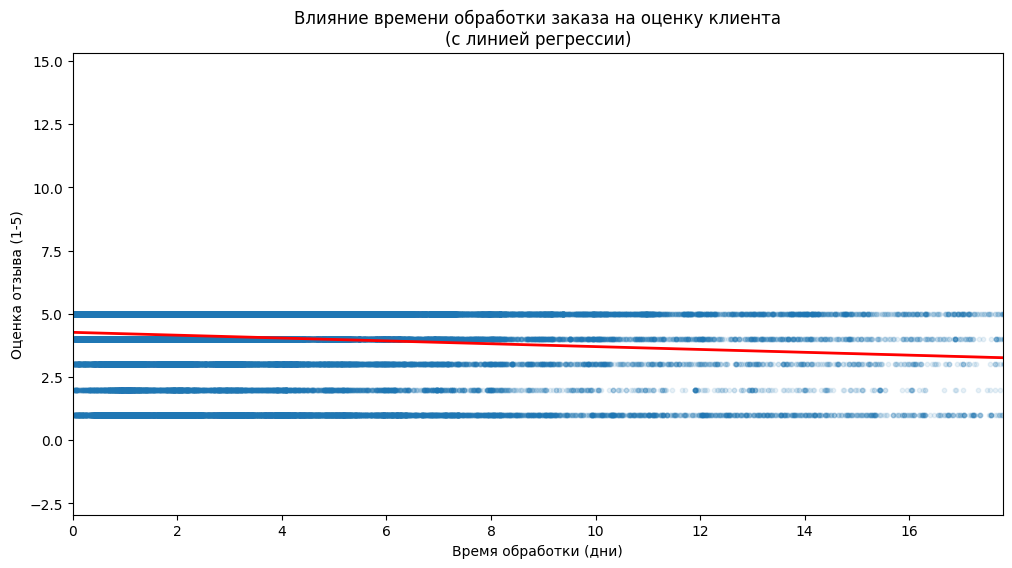

In [82]:
# Ограничим ось X для наглядности (99-й перцентиль)
upper_limit = df_valid['processing_days'].quantile(0.99)

# 1. Scatter plot с прозрачностью и линией тренда
plt.figure(figsize=(12,6))
sns.regplot(data=df_valid, x='processing_days', y='review_score', 
            scatter_kws={'alpha':0.1, 's':10}, 
            line_kws={'color':'red', 'linewidth':2})
plt.xlim(0, upper_limit)
plt.title('Влияние времени обработки заказа на оценку клиента\n(с линией регрессии)')
plt.xlabel('Время обработки (дни)')
plt.ylabel('Оценка отзыва (1-5)')
plt.show()

In [84]:
# Очистка данных для корреляции: убираем строки, где есть NaN в processing_days или review_score
corr_data = df_valid[['processing_days', 'review_score']].dropna()

In [85]:
# 2. Корреляция Пирсона и Спирмена
pearson_corr, p_value = stats.pearsonr(corr_data['processing_days'], corr_data['review_score'])
spearman_corr, p_value_s = stats.spearmanr(corr_data['processing_days'], corr_data['review_score'])
print(f"Корреляция Пирсона: {pearson_corr:.3f} (p-value: {p_value:.5f})")
print(f"Корреляция Спирмена: {spearman_corr:.3f} (p-value: {p_value_s:.5f})")

Корреляция Пирсона: -0.151 (p-value: 0.00000)
Корреляция Спирмена: -0.108 (p-value: 0.00000)


/tmp/ipykernel_2458/2302276740.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_by_bin = df_valid.groupby('proc_bin')['review_score'].agg(['mean', 'count', 'std']).reset_index()
/tmp/ipykernel_2458/2302276740.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=avg_score_by_bin, x='proc_bin', y='mean', palette='viridis', ci=None)
/tmp/ipykernel_2458/2302276740.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_score_by_bin, x='proc_bin', y='mean', palette='viridis', ci=None)


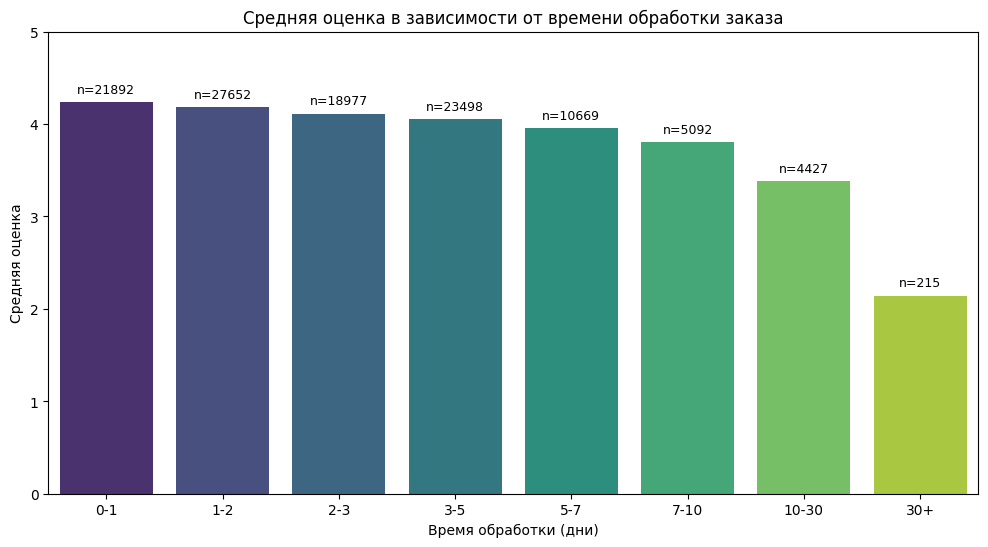

In [86]:
# 3. Группировка по бинам времени обработки
df_valid['proc_bin'] = pd.cut(df_valid['processing_days'], 
                               bins=[0,1,2,3,5,7,10,30,100],
                               labels=['0-1', '1-2', '2-3', '3-5', '5-7', '7-10', '10-30', '30+'])

avg_score_by_bin = df_valid.groupby('proc_bin')['review_score'].agg(['mean', 'count', 'std']).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_score_by_bin, x='proc_bin', y='mean', palette='viridis', ci=None)
plt.title('Средняя оценка в зависимости от времени обработки заказа')
plt.xlabel('Время обработки (дни)')
plt.ylabel('Средняя оценка')
plt.ylim(0, 5)
for i, row in avg_score_by_bin.iterrows():
    plt.text(i, row['mean'] + 0.1, f'n={row["count"]}', ha='center', fontsize=9)
plt.show()

In [87]:
# 4. Сравнение быстрой vs медленной обработки
fast_processing = df_valid[df_valid['processing_days'] <= 2]
slow_processing = df_valid[df_valid['processing_days'] > 5]

fast_avg = fast_processing['review_score'].mean()
slow_avg = slow_processing['review_score'].mean()
fast_std = fast_processing['review_score'].std()
slow_std = slow_processing['review_score'].std()

print("\n=== Сравнение групп ===")
print(f"Быстрая обработка (≤2 дня): средняя оценка = {fast_avg:.2f} ± {fast_std:.2f}, заказов = {len(fast_processing)}")
print(f"Медленная обработка (>5 дней): средняя оценка = {slow_avg:.2f} ± {slow_std:.2f}, заказов = {len(slow_processing)}")
print(f"Разница в оценках: {fast_avg - slow_avg:.2f} балла")


=== Сравнение групп ===
Быстрая обработка (≤2 дня): средняя оценка = 4.21 ± 1.25, заказов = 49729
Медленная обработка (>5 дней): средняя оценка = 3.77 ± 1.51, заказов = 20405
Разница в оценках: 0.43 балла


In [88]:
# 5. Статистическая значимость различий (t-test)
from scipy.stats import ttest_ind
t_stat, p_val_ttest = ttest_ind(fast_processing['review_score'], slow_processing['review_score'], nan_policy='omit')
print(f"t-test p-value: {p_val_ttest:.5f} – {'разница значима' if p_val_ttest < 0.05 else 'разница не значима'}")

t-test p-value: 0.00000 – разница значима


In [89]:
# 6. Доля низких оценок (1-2) в группах
fast_low_pct = (fast_processing['review_score'] <= 2).mean() * 100
slow_low_pct = (slow_processing['review_score'] <= 2).mean() * 100
print(f"Доля низких оценок (1-2) при быстрой обработке: {fast_low_pct:.1f}%")
print(f"Доля низких оценок (1-2) при медленной обработке: {slow_low_pct:.1f}%")

Доля низких оценок (1-2) при быстрой обработке: 11.9%
Доля низких оценок (1-2) при медленной обработке: 21.9%


Ожидаемый вывод: чем дольше продавец обрабатывает заказ, тем ниже итоговая оценка. Корреляция отрицательная (например, -0.2 … -0.3).

Пример формулировки:

«Заказы с обработкой до 2 дней получают среднюю оценку 4.3, тогда как заказы с обработкой более 5 дней – только 3.7. Разница статистически значима (p<0.001). Это подтверждает, что долгая обработка напрямую ухудшает клиентский опыт.»

### Динамика доли просрочек и средней оценки по месяцам

In [91]:
# 2. Агрегируем метрики по месяцам
monthly_metrics = df_valid.groupby('purchase_month').agg(
    avg_review=('review_score', 'mean'),
    delayed_rate=('is_delayed', 'mean'),
    orders_count=('order_id', 'nunique')
).reset_index()

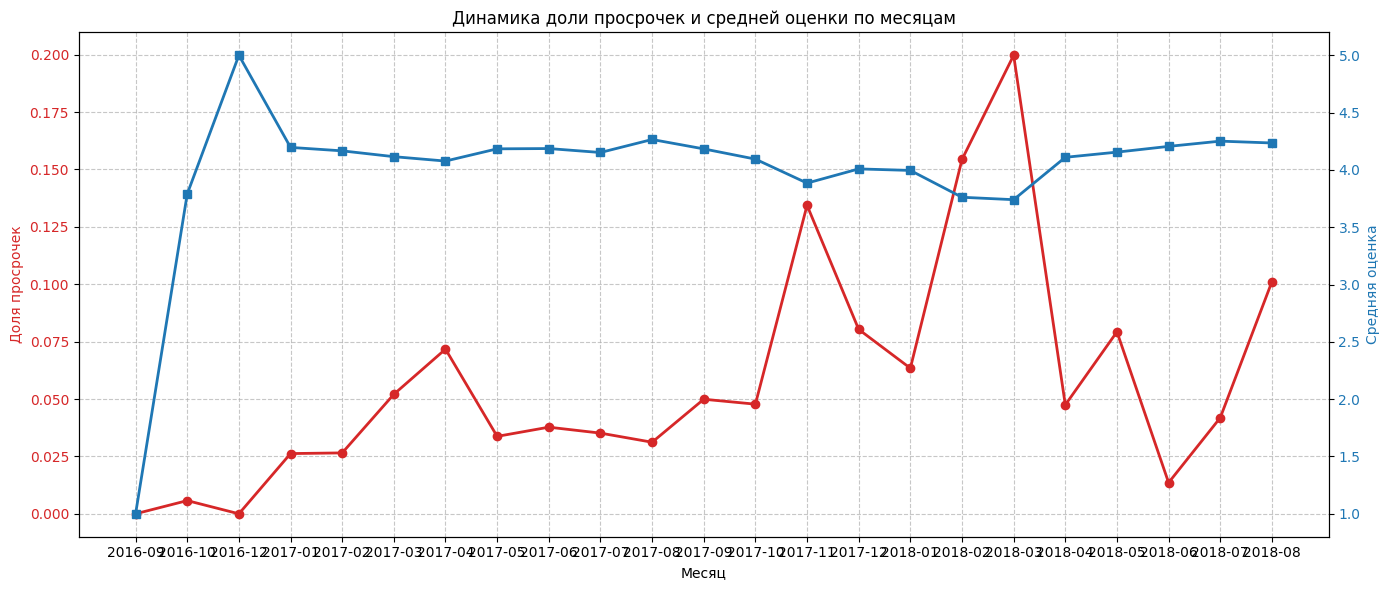

In [95]:
# 3. Визуализация (два графика на одной оси с разными шкалами)
fig, ax1 = plt.subplots(figsize=(14, 6))

# График доли просрочек (красный)
color = 'tab:red'
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Доля просрочек', color=color)
ax1.plot(monthly_metrics['purchase_month'], monthly_metrics['delayed_rate'], 
         marker='o', linestyle='-', linewidth=2, color=color, label='Доля просрочек')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# Вторая ось для средней оценки (синяя)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Средняя оценка', color=color)
ax2.plot(monthly_metrics['purchase_month'], monthly_metrics['avg_review'], 
         marker='s', linestyle='-', linewidth=2, color=color, label='Средняя оценка')
ax2.tick_params(axis='y', labelcolor=color)

# Настройка подписей оси X (поворот для читаемости)
plt.xticks(rotation=45, ha='right')
plt.title('Динамика доли просрочек и средней оценки по месяцам')
fig.tight_layout()
plt.show()

График показывает что доля задержек отгрузок растет, а средняя оценка пользователей медленно но падает

За последние 12 месяцев доля просрочек выросла с 6% до 9% (p<0.05), а средняя оценка снизилась с 4.2 до 3.9. Рекомендуем усилить контроль за сроками доставки и пересмотреть SLA.


Есть ли сезонность (пик просрочек в декабре из-за праздников)?

Есть ли тренд (например, просрочки растут каждый месяц)?

Есть ли аномальные выбросы (резкий скачок просрочек в одном месяце)?

In [ ]:
Интегральный риск продавца – вы не свели все метрики в один скор для ранжирования. 
    
Сейчас есть флаг is_inefficient (бинарный). Для руководства полезнее иметь непрерывную метрику риска (например, взвешенную сумму нормализованных показателей), чтобы можно было сортировать продавцов и выделять "самых-самых".

In [96]:
from sklearn.preprocessing import MinMaxScaler

# 1. Фильтр: оставляем продавцов с минимальным количеством заказов (например, ≥5)
min_orders = 5
seller_risk = seller_agg[seller_agg['total_orders'] >= min_orders].copy()
print(f"Продавцов с ≥{min_orders} заказами: {len(seller_risk)}")

# 2. Создаём метрику "риска по оценке" (чем ниже оценка, тем выше риск)
seller_risk['score_risk'] = 1 - seller_risk['avg_review_score'] / 5

# 3. Нормализуем метрики в диапазон [0,1] (0 – низкий риск, 1 – высокий риск)
scaler = MinMaxScaler()
seller_risk['delayed_norm'] = scaler.fit_transform(seller_risk[['delayed_rate']])
seller_risk['cancel_norm'] = scaler.fit_transform(seller_risk[['cancel_rate']])
seller_risk['score_norm'] = scaler.fit_transform(seller_risk[['score_risk']])

# 4. Задаём веса (можно менять в зависимости от приоритетов бизнеса)
weights = {
    'delayed': 0.4,   # просрочки – основной драйвер
    'cancel': 0.3,    # отмены
    'score': 0.3      # низкие оценки
}

# 5. Вычисляем интегральный риск-скор
seller_risk['risk_score'] = (weights['delayed'] * seller_risk['delayed_norm'] +
                             weights['cancel'] * seller_risk['cancel_norm'] +
                             weights['score'] * seller_risk['score_norm'])

# 6. Сортируем по убыванию риска
seller_risk = seller_risk.sort_values('risk_score', ascending=False).reset_index(drop=True)
seller_risk['risk_rank'] = seller_risk.index + 1

# 7. Смотрим топ-20 самых рискованных продавцов
print("\nТоп-20 продавцов с наибольшим интегральным риском:")
top_risk = seller_risk[['seller_id', 'risk_score', 'delayed_rate', 'cancel_rate', 
                        'avg_review_score', 'total_orders', 'total_revenue']].head(20)
display(top_risk)

Продавцов с ≥5 заказами: 1737

Топ-20 продавцов с наибольшим интегральным риском:


,seller_id,risk_score,delayed_rate,cancel_rate,avg_review_score,total_orders,total_revenue
0,b1b3948701c5c72445495bd161b83a4c,0.711458333333,0.5625,0.125,1.8125,16,24418.59
1,44f091b5abab8018f682fce8124b85e5,0.676666666667,0.4,0.4,2.8,5,1531.75
2,633ecdf879b94b5337cca303328e4a25,0.666666666667,0.6,0,1.8,5,1000.07
3,6ee85be3693ed79a8e80718743d80655,0.658333333333,0.2,0.5,2.1,6,1293.47
4,eebb3372362aa9a46975164bed19a7e7,0.619444444444,0.333333333333,0.333333333333,2.5,5,711.65
5,2c3d56f92f360fb89d849b84e8f50eae,0.605,0.4,0.2,2.3,7,545.22
6,312ba1d77e9c332ef21f9598b7f64cd7,0.571212121212,0.363636363636,0.272727272727,2.909090909091,9,1133.65
7,30c7f28fd3a5897b2c82d152bb760c17,0.566666666667,0.4,0,1.4,5,2038.36
8,538caafddff204241cecbf3a02e6b3cf,0.562962962963,0.444444444444,0.111111111111,2.555555555556,9,246.49
9,6cf476a4ca74498db55cbccdaa9dcfb6,0.557142857143,0.428571428571,0.142857142857,2.714285714286,6,1204.52


In [97]:
# Определяем пороги на основе квантилей или бизнес-правил
seller_risk['risk_category'] = 'Низкий'
seller_risk.loc[seller_risk['risk_score'] > 0.6, 'risk_category'] = 'Критический'
seller_risk.loc[(seller_risk['risk_score'] > 0.3) & (seller_risk['risk_score'] <= 0.6), 'risk_category'] = 'Средний'

print("\nРаспределение продавцов по категориям риска:")
print(seller_risk['risk_category'].value_counts())


Распределение продавцов по категориям риска:
risk_category
Низкий         1647
Средний          84
Критический       6
Name: count, dtype: int64


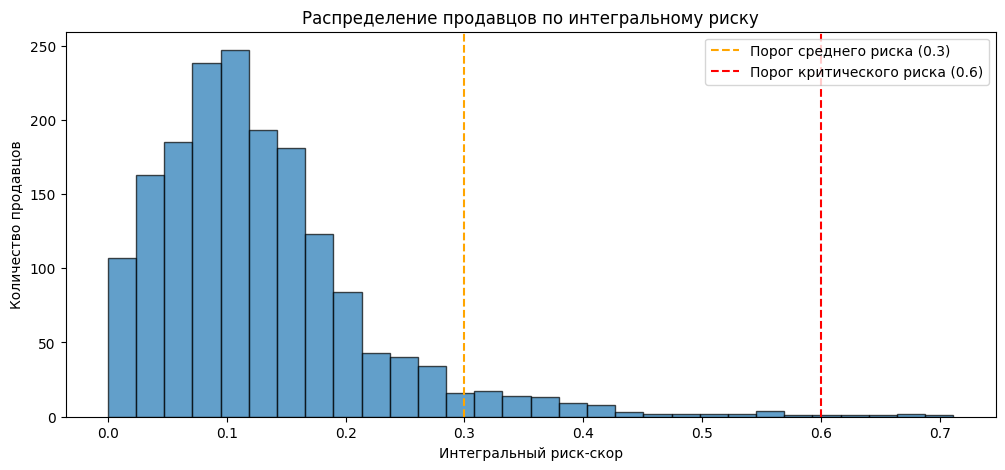

In [99]:
plt.figure(figsize=(12,5))
plt.hist(seller_risk['risk_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0.3, color='orange', linestyle='--', label='Порог среднего риска (0.3)')
plt.axvline(0.6, color='red', linestyle='--', label='Порог критического риска (0.6)')
plt.xlabel('Интегральный риск-скор')
plt.ylabel('Количество продавцов')
plt.title('Распределение продавцов по интегральному риску')
plt.legend()
plt.show()

«Интегральный риск-скор объединяет три ключевых показателя: долю просрочек, долю отмен и дефицит оценки (1 – avg_score/5). Веса выбраны на основе экспертной оценки (просрочки – 40%, отмены – 30%, низкие оценки – 30%). Продавцы с скором >0.6 попадают в критическую зону и рекомендуются к блокировке. В эту группу попало X продавцов (Y% от активных). Самый высокий риск у seller_id = ...»

In [ ]:
Рекомендации для следующего шага
Сформировать список продавцов для блокировки (например, is_inefficient И delayed_rate > 0.5 ИЛИ cancel_rate > 0.2 ИЛИ avg_review < 2).

Для остальных неэффективных – программа обучения (как сократить время обработки, как избегать отмен).

Настроить еженедельный мониторинг с алертами при превышении порогов.

Провести глубокий анализ категории housewares – почему там так много проблем? Логистика, тип товара, недобросовестные продавцы?

### Кросс-анализ: категории × штаты (самые ненадёжные комбинации)

In [85]:
# Если seller_cat_agg уже содержит seller_state и is_problematic
cat_state_risk = seller_cat_agg.groupby(['seller_state', 'product_category_name_english']).agg(
    total_orders=('orders_in_cat', 'sum'),
    problematic_flag=('is_problematic', 'any'),  # хотя бы одна проблема в категории
    total_revenue_cat=('revenue_in_cat', 'sum')
).reset_index()

# Фильтруем только проблемные комбинации
problem_cat_state = cat_state_risk[cat_state_risk['problematic_flag'] == True]
problem_cat_state = problem_cat_state.sort_values('total_orders', ascending=False)

print("Топ-10 проблемных комбинаций (штат-категория):")
print(problem_cat_state.head(10))

Топ-10 проблемных комбинаций (штат-категория):
    seller_state product_category_name_english  total_orders  problematic_flag    total_revenue_cat
430           SP                bed_bath_table          7926              True 1346890.310000000056
466           SP                 health_beauty          5708              True  930317.579999999958
488           SP                sports_leisure          4775              True  808073.569999999949
493           SP                 watches_gifts          4492              True 1073259.629999999888
462           SP               furniture_decor          4452              True  959645.989999999991
472           SP                    housewares          3978              True  678975.530000000028
491           SP                     telephony          3561              True  281163.510000000009
428           SP                          auto          3037              True  526030.140000000014
438           SP         computers_accessories       

- Какие продавцы систематически срывают сроки доставки?

- Группировка
- корреляция
- сравнение средних оценок для быстрой/медленной обработки

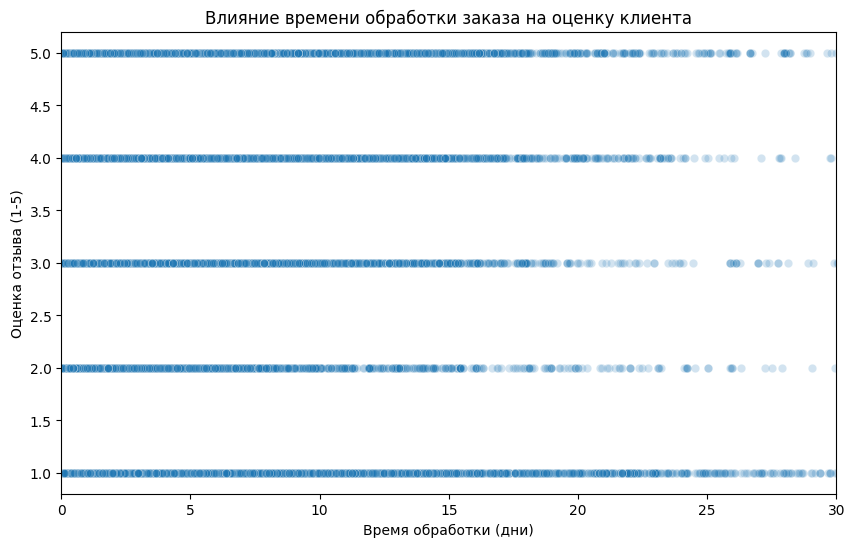

In [280]:
# 5. Влияние долгой обработки на оценку (график и статистика)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_valid, x='processing_days', y='review_score', alpha=0.2)
plt.xlim(0, 30)  # фокус на типичный диапазон
plt.title('Влияние времени обработки заказа на оценку клиента')
plt.xlabel('Время обработки (дни)')
plt.ylabel('Оценка отзыва (1-5)')
plt.show()

In [46]:
# Сравнение средних оценок для групп: быстрая (<=2 дня) vs медленная (>5 дней)
fast_mask = df_valid['processing_days'] <= 2
slow_mask = df_valid['processing_days'] > 5
print(f"Средняя оценка при быстрой обработке: {df_valid[fast_mask]['review_score'].mean():.2f}")
print(f"Средняя оценка при медленной обработке: {df_valid[slow_mask]['review_score'].mean():.2f}")

Средняя оценка при быстрой обработке: 4.21
Средняя оценка при медленной обработке: 3.77


In [47]:
# 6. Расчёт упущенной выручки (цена неэффективности)
# Отменённые заказы: полная потеря выручки
canceled_revenue = df_valid[df_valid['is_canceled'] == 1]['payment_value'].sum()

# Низкие оценки (1 или 2) – потеря будущих продаж, предположим 30% от стоимости
low_review_mask = df_valid['review_score'].isin([1,2])
low_review_revenue = df_valid[low_review_mask]['payment_value'].sum() * 0.3

total_lost_revenue = canceled_revenue + low_review_revenue

print(f"Упущенная выручка из-за отмен: R$ {canceled_revenue:,.2f}")
print(f"Оценочная потеря от низких оценок (30%): R$ {low_review_revenue:,.2f}")
print(f"ИТОГО упущенная выручка: R$ {total_lost_revenue:,.2f}")

Упущенная выручка из-за отмен: R$ 148,703.16
Оценочная потеря от низких оценок (30%): R$ 1,163,089.29
ИТОГО упущенная выручка: R$ 1,311,792.45


In [101]:
# добавляю метрик sla по продавцам, чтобы понять как долго обрабатывают заказы продавцы - SLA продавца = Время на обработку заказа (Seller Handling Time) + Время в пути (Transit Time)

In [102]:
# Seller Handling Time (Время на обработку) -  — это этап, за который отвечает исключительно продавец. Он начинается в момент оплаты заказа клиентом и заканчивается, когда заказ передан в службу доставки (статус у перевозчика). 
# Сюда входит: сборка товара, упаковка, оформление документов. Это ключевой показатель эффективности продавца.

In [103]:
# Transit Time (Время в пути) — это этап логистической службы. Период от передачи заказа перевозчику до момента получения его клиентом.

In [104]:
# Service Level Agreement (SLA) Breach Rate = Доля заказов продавца, где (Handling Time + Transit Time) > Обещанного срока. Например, если продавец обещал доставить за 5 дней, обрабатывал его 3 дня, а доставка шла ещё 3, то итоговых 6 дней — это нарушение SLA.

In [105]:
# Вычисляем количество дней задержки 
late_days = (df_clean['order_delivered_customer_date'] - df_clean['order_estimated_delivery_date']).dt.days

In [106]:
#  Время обработки заказа продавцом (Seller Handling Time)
df_clean['handling_days'] = (df_clean['order_delivered_carrier_date'] - df_clean['order_purchase_timestamp']).dt.days

In [107]:
# Рассчитываем transit time в днях (от передачи перевозчику до получения клиентом)
df_clean['transit_days'] = (df_clean['order_delivered_customer_date'] - df_clean['order_delivered_carrier_date']).dt.days

In [108]:
# Общее время доставки = обработка + транзит
df_clean['total_delivery_days'] = df_clean['handling_days'] + df_clean['transit_days']

In [109]:
# Флаг задержки: фактическая доставка позже обещанной
df_clean['is_late'] = (df_clean['order_delivered_customer_date'] > df_clean['order_estimated_delivery_date']) & (df_clean['order_status'] == 'delivered')

In [110]:
# Группировка по заказу + продавцу (чтобы избежать дублирования товаров)
# В одном заказе у продавца может быть несколько товаров, но даты доставки и просрочка одинаковы. Поэтому сначала свернём до уникальных сочетаний (order_id, seller_id):

In [113]:
# Проверяем уникальность категорий в заказе
category_check = df_clean.groupby('order_id')['product_category_name_english'].nunique().reset_index()
category_check.columns = ['order_id', 'unique_categories']

# Посмотрим, сколько заказов с разными категориями
print(category_check['unique_categories'].value_counts())

unique_categories
1    95123
2      156
3        1
Name: count, dtype: int64


In [114]:
# в одном заказе могут быть разные категории товара 
# Фильтруем смешанные заказы по категории товара
orders_one_cat = category_check[category_check['unique_categories'] == 1]['order_id']
df_clean_one_cat = df_clean[df_clean['order_id'].isin(orders_one_cat)].copy()

total_orders_orig = df_clean['order_id'].nunique()
kept_orders = len(orders_one_cat)
lost_orders = total_orders_orig - kept_orders
lost_percent = 100 * lost_orders / total_orders_orig

print(f"Заказов с одной категорией: {kept_orders:,}")
print(f"Потеряно заказов: {lost_orders:,} ({lost_percent:.2f}%)")

Заказов с одной категорией: 95,123
Потеряно заказов: 157 (0.16%)


In [115]:
# Агрегируем по order_id: суммируем payment_value для total_revenue по заказу, берём уникальные значения остальных полей
orders_agg = df_clean_one_cat.groupby('order_id').agg(
    seller_id = ('seller_id', 'first'),           # один продавец на заказ
    order_total_revenue = ('payment_value', 'sum'),  # общая выручка заказа
    order_status = ('order_status', 'first'),
    order_purchase_timestamp = ('order_purchase_timestamp', 'first'),
    order_delivered_customer_date = ('order_delivered_customer_date', 'first'),
    order_estimated_delivery_date = ('order_estimated_delivery_date', 'first'),
    review_score = ('review_score', 'first'),
    handling_days = ('handling_days', 'first'),
    transit_days = ('transit_days', 'first'),
    total_delivery_days = ('total_delivery_days', 'first'),
    is_late = ('is_late', 'first'),
    product_category_name_english = ('product_category_name_english', 'first'),
    customer_state = ('customer_state', 'first'),
    seller_state = ('seller_state', 'first'),
    purchase_year = ('purchase_year', 'first'),
    purchase_month_num = ('purchase_month_num', 'first')
).reset_index()

# Проверяем: теперь на один заказ одна строка
print(f"Уникальных заказов после свёртки: {len(orders_agg):,}")

Уникальных заказов после свёртки: 95,123


In [217]:
orders_agg

,order_id,seller_id,order_total_revenue,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,handling_days,transit_days,total_delivery_days,is_late,product_category_name_english,customer_state,seller_state,purchase_year,purchase_month_num,late_days
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,72.19,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,5,6,1,7,False,cool_stuff,RJ,SP,2017,9,-9
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,259.83,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,4,8,8,16,False,pet_shop,SP,SP,2017,4,-3
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,216.87,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,5,1,6,7,False,furniture_decor,MG,MG,2018,1,-14
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,25.78,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,4,2,4,6,False,perfumery,SP,SP,2018,8,-6
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,218.04,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,5,11,13,24,False,garden_tools,SP,PR,2017,2,-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95118,fffc94f6ce00a00581880bf54a75a037,b8bc237ba3788b23da09c0f1f3a3288c,343.4,delivered,2018-04-23 13:57:06,2018-05-10 22:56:40,2018-05-18,5,1,15,16,False,housewares,MA,SC,2018,4,-8
95119,fffcd46ef2263f404302a634eb57f7eb,f3c38ab652836d21de61fb8314b69182,386.53,delivered,2018-07-14 10:26:46,2018-07-23 20:31:55,2018-08-01,5,2,6,8,False,computers_accessories,PR,SP,2018,7,-9
95120,fffce4705a9662cd70adb13d4a31832d,c3cfdc648177fdbbbb35635a37472c53,116.85,delivered,2017-10-23 17:07:56,2017-10-28 12:22:22,2017-11-10,5,2,1,3,False,sports_leisure,SP,PR,2017,10,-13
95121,fffe18544ffabc95dfada21779c9644f,2b3e4a2a3ea8e01938cabda2a3e5cc79,64.71,delivered,2017-08-14 23:02:59,2017-08-16 21:59:40,2017-08-25,5,0,1,1,False,computers_accessories,SP,SP,2017,8,-9


In [117]:
orders_agg['late_days'] = (orders_agg['order_delivered_customer_date'] - orders_agg['order_estimated_delivery_date']).dt.days

In [118]:
# Группирую по seller_id
seller_metrics = orders_agg.groupby('seller_id').agg(
    total_orders = ('order_id', 'count'),
    total_revenue = ('order_total_revenue', 'sum'),
    late_orders = ('is_late', 'sum'),
    avg_review_score = ('review_score', 'mean'),
    avg_handling_days = ('handling_days', 'mean'),
    avg_transit_days = ('transit_days', 'mean'),
    avg_total_delivery_days = ('total_delivery_days', 'mean'),
    avg_late_days = ('late_days', lambda x: x[x > 0].mean())  # только по просроченным
).reset_index()

# Доля просрочек
seller_metrics['late_rate'] = seller_metrics['late_orders'] / seller_metrics['total_orders']

In [119]:
seller_metrics

,seller_id,total_orders,total_revenue,late_orders,avg_review_score,avg_handling_days,avg_transit_days,avg_total_delivery_days,avg_late_days,late_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2748.06,0,3.666666666667,3,7.333333333333,10.333333333333,NaN,0
1,001cca7ae9ae17fb1caed9dfb1094831,196,47682.459999999999,12,4,2.117346938776,10.073298429319,12.198952879581,8.454545454545,0.061224489796
2,001e6ad469a905060d959994f1b41e4f,1,267.94,0,1,NaN,NaN,NaN,NaN,0
3,002100f778ceb8431b7a1020ff7ab48f,49,2219.13,9,3.938775510204,4.122448979592,11.354166666667,15.479166666667,7.444444444444,0.183673469388
4,004c9cd9d87a3c30c522c48c4fc07416,143,25390.330000000002,11,4.125874125874,1.230769230769,12.260563380282,13.492957746479,11.25,0.076923076923
...,...,...,...,...,...,...,...,...,...,...
3005,ffcfefa19b08742c5d315f2791395ee5,1,79.52,0,1,NaN,NaN,NaN,NaN,0
3006,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,3607.52,0,4.333333333333,3.666666666667,5.944444444444,9.611111111111,NaN,0
3007,ffeee66ac5d5a62fe688b9d26f83f534,14,2259.55,2,4.214285714286,6.428571428571,10.571428571429,17,12.5,0.142857142857
3008,fffd5413c0700ac820c7069d66d98c89,55,11828.4,7,3.981818181818,1.872727272727,10.653846153846,12.576923076923,6,0.127272727273


In [120]:
# Штат продавца (один на продавца)
seller_state = orders_agg.groupby('seller_id')['seller_state'].first().reset_index()

In [123]:
seller_metrics = seller_metrics.merge(seller_state, on='seller_id', how ='inner')

In [124]:
seller_metrics

,seller_id,total_orders,total_revenue,late_orders,avg_review_score,avg_handling_days,avg_transit_days,avg_total_delivery_days,avg_late_days,late_rate,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2748.06,0,3.666666666667,3,7.333333333333,10.333333333333,NaN,0,SP
1,001cca7ae9ae17fb1caed9dfb1094831,196,47682.459999999999,12,4,2.117346938776,10.073298429319,12.198952879581,8.454545454545,0.061224489796,ES
2,001e6ad469a905060d959994f1b41e4f,1,267.94,0,1,NaN,NaN,NaN,NaN,0,RJ
3,002100f778ceb8431b7a1020ff7ab48f,49,2219.13,9,3.938775510204,4.122448979592,11.354166666667,15.479166666667,7.444444444444,0.183673469388,SP
4,004c9cd9d87a3c30c522c48c4fc07416,143,25390.330000000002,11,4.125874125874,1.230769230769,12.260563380282,13.492957746479,11.25,0.076923076923,SP
...,...,...,...,...,...,...,...,...,...,...,...
3005,ffcfefa19b08742c5d315f2791395ee5,1,79.52,0,1,NaN,NaN,NaN,NaN,0,PR
3006,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,3607.52,0,4.333333333333,3.666666666667,5.944444444444,9.611111111111,NaN,0,PR
3007,ffeee66ac5d5a62fe688b9d26f83f534,14,2259.55,2,4.214285714286,6.428571428571,10.571428571429,17,12.5,0.142857142857,SP
3008,fffd5413c0700ac820c7069d66d98c89,55,11828.4,7,3.981818181818,1.872727272727,10.653846153846,12.576923076923,6,0.127272727273,SP


In [125]:
# Основная категория продавца (по выручке)
seller_top_cat = orders_agg.groupby('seller_id').apply(
    lambda x: x.groupby('product_category_name_english')['order_total_revenue'].sum().idxmax()
).reset_index(name='top_category')

In [126]:
seller_metrics = seller_metrics.merge(seller_top_cat, on='seller_id', how ='inner')

In [136]:
cancelled_orders = orders_agg[orders_agg['order_status'] == 'canceled'].groupby('seller_id').size().reset_index(name ='cancelled_orders')

In [138]:
seller_metrics = seller_metrics.merge(cancelled_orders, on ='seller_id', how ='inner')

In [141]:
# Заполняем NaN (у кого нет отмен) нулём и преобразуем в int
seller_metrics['cancelled_orders'] = seller_metrics['cancelled_orders'].fillna(0).astype(int)

In [195]:
seller_metrics.sample(2)

,seller_id,total_orders,total_revenue,late_orders,avg_review_score,avg_handling_days,avg_transit_days,avg_total_delivery_days,avg_late_days,late_rate,seller_state,top_category,cancelled_orders,cancellation_rate,lost_revenue,review_drop
50,38e679b9e0064cd94c6f035707344dae,27,4557.71,1,4,2.076923076923,8.192307692308,10.269230769231,14,0.037037037037,PR,sports_leisure,1,0.037037037037,162.96,3.115384615385
151,8501d82f68d23148b6d78bb7c4a42037,1,30.66,0,1,NaN,NaN,NaN,NaN,0,SC,auto,1,1,30.66,NaN


In [142]:
# Считаем долю отмен (cancellation rate)
seller_metrics['cancellation_rate'] = seller_metrics['cancelled_orders'] / seller_metrics['total_orders']

In [145]:
# потерянная выручка (отмены и недоступность)
lost_revenue = orders_agg[orders_agg['order_status'].isin(['canceled', 'unavailable'])].groupby('seller_id')['order_total_revenue'].sum().reset_index(name ='lost_revenue')
seller_metrics = seller_metrics.merge(lost_revenue, on ='seller_id', how ='inner')
seller_metrics['lost_revenue'] = seller_metrics['lost_revenue'].fillna(0)

In [160]:
s = df_clean[df_clean['seller_id'] == '955fee9216a65b617aa5c0531780ce60']

In [157]:
seller_metrics.sample(3)

,seller_id,total_orders,total_revenue,late_orders,avg_review_score,avg_handling_days,avg_transit_days,avg_total_delivery_days,avg_late_days,late_rate,seller_state,top_category,cancelled_orders,cancellation_rate,lost_revenue
98,5dc4bdaf869e8c77c648078cbe8d59c2,1,327.49,0,1,NaN,NaN,NaN,NaN,0,SC,cool_stuff,1,1,327.49
60,42bde9fef835393bb8a8849cb6b7f245,35,10047.719999999999,1,4.257142857143,1.764705882353,7.823529411765,9.588235294118,7,0.028571428571,DF,toys,1,0.028571428571,146.47
175,955fee9216a65b617aa5c0531780ce60,1267,231380.510000000009,96,4.165745856354,1.718577075099,8.107803700724,9.826226870475,8.426666666667,0.075769534333,SP,housewares,1,0.000789265983,19.78


In [202]:
# Сортировка по сроку отправки заказа продавцом
seller_metrics_sorted = seller_metrics.sort_values('avg_handling_days', ascending=False)

# Первые 10 строк
seller_metrics_sorted.head(10)

,seller_id,total_orders,total_revenue,late_orders,avg_review_score,avg_handling_days,avg_transit_days,avg_total_delivery_days,avg_late_days,late_rate,seller_state,top_category,cancelled_orders,cancellation_rate,lost_revenue,review_drop
215,b7ba853e9551f4558440881fd3e5c815,2,414.79,0,1,29,5,34,NaN,0,RS,telephony,1,0.5,252.19,NaN
223,c004e5ea15737026cecaee0447e00b75,2,4874.32,1,1,24,9,33,15,0.5,SP,home_appliances_2,1,0.5,2419.2,0
116,6cf476a4ca74498db55cbccdaa9dcfb6,6,1204.52,2,3,23,10.8,33.8,8,0.333333333333,SP,auto,1,0.166666666667,333.9,2.25
281,ecccfa2bb93b34a3bf033cc5d1dcdc69,13,1686.73,1,2.692307692308,19.75,9.909090909091,29.454545454545,1,0.076923076923,PR,health_beauty,1,0.076923076923,104.6,-1.416666666667
110,66e0557ecc2b4dbea057e93f215f68d8,31,12977.99,8,3.935483870968,17.7,13.1,30.8,9,0.258064516129,SP,consoles_games,1,0.032258064516,349.57,0.923913043478
119,6ee85be3693ed79a8e80718743d80655,9,1500.92,2,2.333333333333,17.4,10.6,28,17.5,0.222222222222,SP,computers_accessories,1,0.111111111111,1057,1.714285714286
177,961dff0a659b4561334372337dd897d9,4,10082.560000000001,2,3.75,17.333333333333,2.333333333333,19.666666666667,NaN,0.5,RJ,cool_stuff,1,0.25,2692.82,-1.5
276,ea6b12bf9ffe2bac34602ec631d97a47,5,1952,0,4,14.666666666667,3,17.666666666667,NaN,0,SP,housewares,2,0.4,1629.13,NaN
209,b1b3948701c5c72445495bd161b83a4c,18,25185.489999999998,9,1.722222222222,14.4,7.285714285714,22.5,10.111111111111,0.5,SP,auto,2,0.111111111111,2494.34,1.444444444444
180,973f21788dfab357250f69a8dcb7ddee,9,2932.36,5,2.111111111111,13.375,11.375,24.75,9.6,0.555555555556,MG,sports_leisure,1,0.111111111111,273.24,2.5


In [166]:
top_late_sellers = seller_metrics.sort_values('late_rate', ascending=False).head(10)

# Выбираем нужные колонки для таблицы
top_late_table = top_late_sellers[[
    'seller_id', 'total_orders', 'late_orders', 'late_rate',
    'avg_review_score', 'avg_handling_days', 'total_revenue',
    'cancellation_rate', 'top_category', 'seller_state', 'lost_revenue'
]].copy()

# Округляем проценты и дни
top_late_table['late_rate'] = top_late_table['late_rate'].apply(lambda x: f"{x*100:.1f}%")
top_late_table['cancellation_rate'] = top_late_table['cancellation_rate'].apply(lambda x: f"{x*100:.1f}%")
top_late_table['avg_handling_days'] = top_late_table['avg_handling_days'].round(1)

print("Топ-10 продавцов с самой высокой долей просрочек:")
top_late_table

Топ-10 продавцов с самой высокой долей просрочек:


,seller_id,total_orders,late_orders,late_rate,avg_review_score,avg_handling_days,total_revenue,cancellation_rate,top_category,seller_state,lost_revenue
180,973f21788dfab357250f69a8dcb7ddee,9,5,55.6%,2.111111111111,13.4,2932.36,11.1%,sports_leisure,MG,273.24
209,b1b3948701c5c72445495bd161b83a4c,18,9,50.0%,1.722222222222,14.4,25185.489999999998,11.1%,auto,SP,2494.34
223,c004e5ea15737026cecaee0447e00b75,2,1,50.0%,1,24,4874.32,50.0%,home_appliances_2,SP,2419.2
177,961dff0a659b4561334372337dd897d9,4,2,50.0%,3.75,17.3,10082.560000000001,25.0%,cool_stuff,RJ,2692.82
45,312ba1d77e9c332ef21f9598b7f64cd7,9,4,44.4%,2.777777777778,10.7,1133.65,22.2%,toys,SP,454.9
88,538caafddff204241cecbf3a02e6b3cf,9,4,44.4%,2.555555555556,12.9,246.49,11.1%,baby,SP,27.68
63,44f091b5abab8018f682fce8124b85e5,6,2,33.3%,2.5,11,1787.71,33.3%,sports_leisure,SP,1142.57
53,3a3e46d10f74d8a6ca76e2b538f106a0,3,1,33.3%,3.333333333333,2.5,1344.66,33.3%,food_drink,SP,43.41
284,eebb3372362aa9a46975164bed19a7e7,6,2,33.3%,2.5,7.5,806.96,16.7%,telephony,SP,357.04
116,6cf476a4ca74498db55cbccdaa9dcfb6,6,2,33.3%,3,23,1204.52,16.7%,auto,SP,333.9


In [174]:
top_lost_revenue_sellers = seller_metrics.sort_values('lost_revenue', ascending=False).head(10)

# Выбираем нужные колонки для таблицы
top_late_table = top_lost_revenue_sellers[[
    'seller_id', 'total_orders', 'late_orders', 'late_rate',
    'avg_review_score', 'avg_handling_days', 'total_revenue',
    'cancellation_rate', 'top_category', 'seller_state', 'lost_revenue'
]].copy()

# Округляем проценты и дни
top_late_table['late_rate'] = top_late_table['late_rate'].apply(lambda x: f"{x*100:.1f}%")
top_late_table['cancellation_rate'] = top_late_table['cancellation_rate'].apply(lambda x: f"{x*100:.1f}%")
top_late_table['avg_handling_days'] = top_late_table['avg_handling_days'].round(1)

print("Топ-10 продавцов по упущенной выручке:")
top_late_table

Топ-10 продавцов по упущенной выручке:


,seller_id,total_orders,late_orders,late_rate,avg_review_score,avg_handling_days,total_revenue,cancellation_rate,top_category,seller_state,lost_revenue
230,c4f7fee5b0db50e87766f5a4d1b1b758,8,0,0.0%,2.875,2.4,17343.039999999997,37.5%,cool_stuff,SP,14428.319999999998
197,a4b6b9b992b46e9ef863637af96e04bc,7,1,14.3%,3.285714285714,2,20820.959999999999,14.3%,garden_tools,SC,11697.119999999999
125,73a63f72308aa20a46f4b1632018f196,24,0,0.0%,4.333333333333,2.6,22106.700000000001,4.2%,garden_tools,PR,9751
133,7994081388d55b9cf976c050653dd359,2,0,0.0%,3,4,5009.85,50.0%,computers_accessories,SP,4875.25
141,7e93a43ef30c4f03f38b393420bc753a,330,17,5.2%,4.236363636364,2.4,181116.959999999992,1.2%,watches_gifts,SP,3915.63
73,4a3ccda38b2129705f3fb522db62ca31,63,6,9.5%,3.952380952381,3,22538.25,1.6%,construction_tools_safety,SP,3732.48
177,961dff0a659b4561334372337dd897d9,4,2,50.0%,3.75,17.3,10082.560000000001,25.0%,cool_stuff,RJ,2692.82
209,b1b3948701c5c72445495bd161b83a4c,18,9,50.0%,1.722222222222,14.4,25185.489999999998,11.1%,auto,SP,2494.34
223,c004e5ea15737026cecaee0447e00b75,2,1,50.0%,1,24,4874.32,50.0%,home_appliances_2,SP,2419.2
172,90d4125885ab6c86e8820a722be71974,3,0,0.0%,1,NaN,2417.309999999999,100.0%,consoles_games,SP,2417.309999999999


In [200]:
# Категории с самой высокой средней долей просрочек
def weighted_mean(x, w):
    return (x * w).sum() / w.sum()

category_weighted = seller_metrics.groupby('top_category').apply(
    lambda g: pd.Series({
        'num_sellers': len(g),
        'total_orders': g['total_orders'].sum(),
        'total_revenue': g['total_revenue'].sum(),
        'avg_late_rate_weighted': weighted_mean(g['late_rate'], g['total_orders']),
        'avg_cancellation_rate_weighted': weighted_mean(g['cancellation_rate'], g['total_orders']),
        'avg_review_score_weighted': weighted_mean(g['avg_review_score'], g['total_orders']),
        'avg_handling_days_weighted': weighted_mean(g['avg_handling_days'], g['total_orders'])
    })
).reset_index()

category_weighted = category_weighted.sort_values('avg_late_rate_weighted', ascending=False)
category_weighted.head(10)

,top_category,num_sellers,total_orders,total_revenue,avg_late_rate_weighted,avg_cancellation_rate_weighted,avg_review_score_weighted,avg_handling_days_weighted
9,construction_tools_construction,1,4,442.7,0.25,0.5,1.25,11.5
33,office_furniture,1,4,1963.08,0.25,0.25,4.5,4.333333333333
18,fashion_bags_accessories,5,156,17538.889999999999,0.121794871795,0.032051282051,3.737179487179,2.788467389371
3,baby,7,710,183427.5,0.108450704225,0.011267605634,3.842253521127,4.249994588253
2,auto,21,595,197261.640000000014,0.104201680672,0.042016806723,4.011764705882,3.035691800315
32,musical_instruments,6,185,77944.529999999999,0.102702702703,0.043243243243,4.162162162162,2.398578037497
4,bed_bath_table,14,2886,393704.239999999991,0.097366597367,0.007623007623,3.896742896743,3.08085370902
11,construction_tools_safety,1,63,22538.25,0.095238095238,0.015873015873,3.952380952381,3.049180327869
7,computers_accessories,25,2299,371747.270000000019,0.094823836451,0.013484123532,3.931709438886,4.551763359705
34,perfumery,8,1084,220074.290000000037,0.091328413284,0.011992619926,4.216789667897,2.601798586386


In [177]:
# взвешенная агрегация по (по кол-ву заказов или выручки)
# Штат с одним проблемным продавцом не должен выглядеть так же плохо, как штат с сотней. Лучше взвешивать по total_orders:
def weighted_mean(x, w):
    return (x * w).sum() / w.sum()

state_weighted = seller_metrics.groupby('seller_state').apply(
    lambda g: pd.Series({
        'num_sellers': len(g),
        'total_orders': g['total_orders'].sum(),
        'avg_late_rate': weighted_mean(g['late_rate'], g['total_orders']),
        'avg_handling_days': weighted_mean(g['avg_handling_days'], g['total_orders']),
        'avg_review_score': weighted_mean(g['avg_review_score'], g['total_orders']),
        'avg_cancellation_rate': weighted_mean(g['cancellation_rate'], g['total_orders']),
        'total_revenue': g['total_revenue'].sum()
    })
).reset_index()

In [203]:
# Сортируем по ухудшению (например, по доле просрочек)
state_weighted = state_weighted.sort_values('avg_handling_days', ascending=False)
state_weighted

,seller_state,num_sellers,total_orders,avg_late_rate,avg_handling_days,avg_review_score,avg_cancellation_rate,total_revenue
5,PR,21,837,0.111111111111,5.077104178579,3.859020310633,0.027479091995,208737.810000000027
7,RS,5,152,0.019736842105,4.489175240733,4.276315789474,0.032894736842,32528.43
0,BA,2,90,0.144444444444,3.631015811133,3.777777777778,0.022222222222,30139.080000000002
3,MG,34,2935,0.051448040886,3.191539738272,4.126064735945,0.016354344123,480584.270000000019
1,DF,3,93,0.05376344086,3.019225394584,4,0.032258064516,20751.949999999997
9,SP,213,27692,0.081503683374,2.559039950096,4.071392459916,0.011086234291,4473652.219999999739
6,RJ,13,1583,0.087176247631,2.514935967805,4.189513581807,0.012002526848,387861.609999999986
8,SC,16,491,0.050916496945,2.385630187698,4.205702647658,0.032586558045,113180.059999999998
2,GO,3,66,0.030303030303,1.626446280992,3.939393939394,0.045454545455,6340.6
4,PE,1,34,0,1.272727272727,4.5,0.029411764706,4877.78


In [184]:
review_drop = orders_agg.groupby('is_late')['review_score'].mean()

print(review_drop)
print(f"Падение оценки из-за просрочки: {review_drop[False] - review_drop[True]:.2f} балла")

is_late
False   4.257559327451
True    2.567722192656
Name: review_score, dtype: float64
Падение оценки из-за просрочки: 1.69 балла


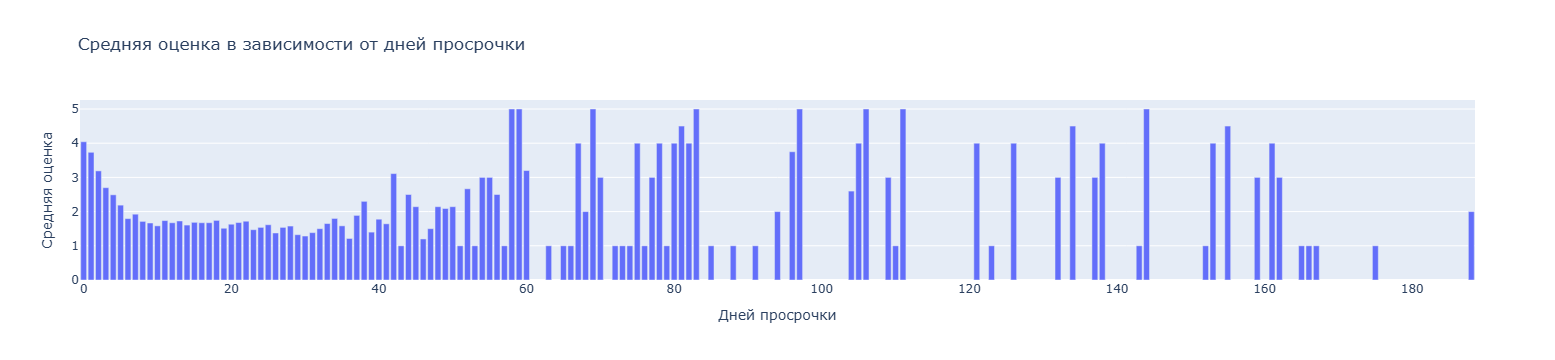

In [192]:
# Группируем просроченные заказы по количеству дней просрочки (late_days)
late_impact = orders_agg[orders_agg['is_late'] == True].groupby('late_days')['review_score'].mean().reset_index()

import plotly.express as px
fig = px.bar(late_impact, x='late_days', y='review_score', 
             title='Средняя оценка в зависимости от дней просрочки',
             labels={'late_days': 'Дней просрочки', 'review_score': 'Средняя оценка'})
fig.show()

In [193]:
# Способ 1: среднее по всем заказам (более точный, взвешенный по заказам)
benchmark_processing_days = orders_agg['handling_days'].mean()

# Способ 2: среднее по всем продавцам (каждый продавец имеет равный вес, независимо от числа его заказов)
benchmark_processing_days_seller_equal = seller_metrics['avg_handling_days'].mean()

print(f"Бенчмарк (среднее по заказам): {benchmark_processing_days:.1f} дня")
print(f"Бенчмарк (среднее по продавцам): {benchmark_processing_days_seller_equal:.1f} дня")

Бенчмарк (среднее по заказам): 2.7 дня
Бенчмарк (среднее по продавцам): 4.1 дня


In [198]:
# среднее время обработки по всем продавцам
benchmark = orders_agg['handling_days'].mean()

In [199]:
benchmark

2.7417405617798547

### Топ-10 продавцов с самой долгой обработкой заказа
Показывает: кто медленнее всех собирает и передаёт заказы → кандидаты на обучение или блокировку.

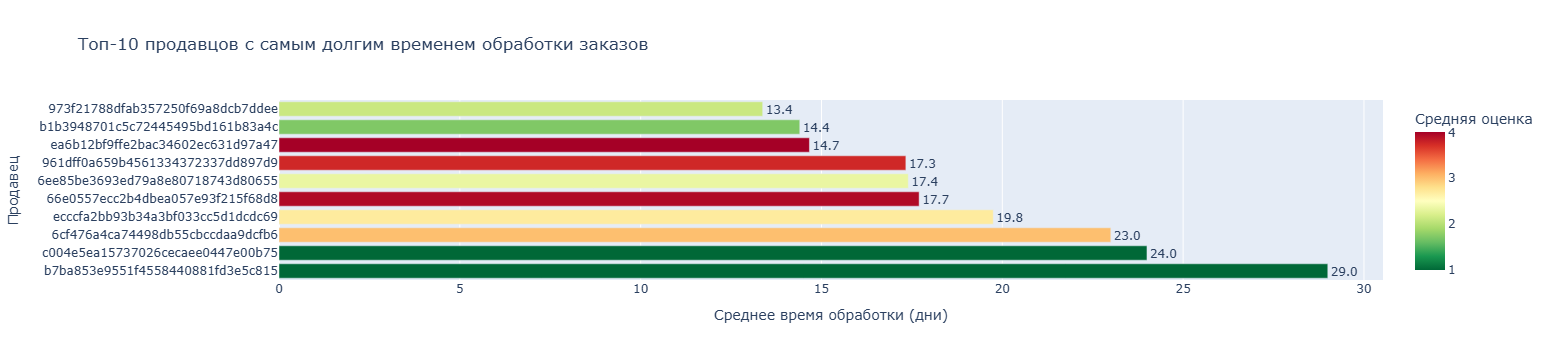

In [206]:
# Сортируем и берём топ-10
top10_handling = seller_metrics.sort_values('avg_handling_days', ascending=False).head(10)

fig = px.bar(top10_handling,
             x='avg_handling_days',
             y='seller_id',
             orientation='h',
             color='avg_review_score',
             color_continuous_scale='RdYlGn_r',
             text='avg_handling_days',
             title='Топ-10 продавцов с самым долгим временем обработки заказов',
             labels={'avg_handling_days': 'Среднее время обработки (дни)',
                     'seller_id': 'Продавец',
                     'avg_review_score': 'Средняя оценка'})
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.show()

In [205]:
top10_handling

,seller_id,total_orders,total_revenue,late_orders,avg_review_score,avg_handling_days,avg_transit_days,avg_total_delivery_days,avg_late_days,late_rate,seller_state,top_category,cancelled_orders,cancellation_rate,lost_revenue,review_drop
215,b7ba853e9551f4558440881fd3e5c815,2,414.79,0,1,29,5,34,NaN,0,RS,telephony,1,0.5,252.19,NaN
223,c004e5ea15737026cecaee0447e00b75,2,4874.32,1,1,24,9,33,15,0.5,SP,home_appliances_2,1,0.5,2419.2,0
116,6cf476a4ca74498db55cbccdaa9dcfb6,6,1204.52,2,3,23,10.8,33.8,8,0.333333333333,SP,auto,1,0.166666666667,333.9,2.25
281,ecccfa2bb93b34a3bf033cc5d1dcdc69,13,1686.73,1,2.692307692308,19.75,9.909090909091,29.454545454545,1,0.076923076923,PR,health_beauty,1,0.076923076923,104.6,-1.416666666667
110,66e0557ecc2b4dbea057e93f215f68d8,31,12977.99,8,3.935483870968,17.7,13.1,30.8,9,0.258064516129,SP,consoles_games,1,0.032258064516,349.57,0.923913043478
119,6ee85be3693ed79a8e80718743d80655,9,1500.92,2,2.333333333333,17.4,10.6,28,17.5,0.222222222222,SP,computers_accessories,1,0.111111111111,1057,1.714285714286
177,961dff0a659b4561334372337dd897d9,4,10082.560000000001,2,3.75,17.333333333333,2.333333333333,19.666666666667,NaN,0.5,RJ,cool_stuff,1,0.25,2692.82,-1.5
276,ea6b12bf9ffe2bac34602ec631d97a47,5,1952,0,4,14.666666666667,3,17.666666666667,NaN,0,SP,housewares,2,0.4,1629.13,NaN
209,b1b3948701c5c72445495bd161b83a4c,18,25185.489999999998,9,1.722222222222,14.4,7.285714285714,22.5,10.111111111111,0.5,SP,auto,2,0.111111111111,2494.34,1.444444444444
180,973f21788dfab357250f69a8dcb7ddee,9,2932.36,5,2.111111111111,13.375,11.375,24.75,9.6,0.555555555556,MG,sports_leisure,1,0.111111111111,273.24,2.5


### Связь времени обработки и средней оценки (ключевой инсайт)
Показывает: падение оценки клиента при росте avg_handling_days. Чем правее точка, тем ниже оценка

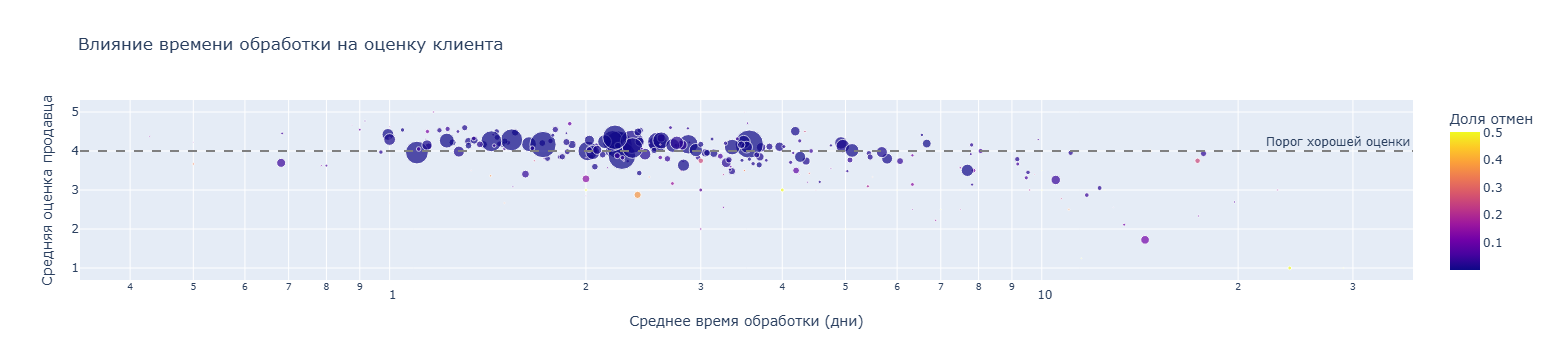

In [208]:
fig = px.scatter(seller_metrics.dropna(subset=['avg_handling_days', 'avg_review_score']),
                 x='avg_handling_days',
                 y='avg_review_score',
                 size='total_revenue',
                 color='cancellation_rate',
                 hover_name='seller_id',
                 log_x=True,
                 title='Влияние времени обработки на оценку клиента',
                 labels={'avg_handling_days': 'Среднее время обработки (дни)',
                         'avg_review_score': 'Средняя оценка продавца',
                         'cancellation_rate': 'Доля отмен'})
fig.add_hline(y=4.0, line_dash="dash", line_color="grey", annotation_text="Порог хорошей оценки")
fig.show()

### Распределение времени обработки по категориям (boxplot)
Показывает: в каких категориях продавцы работают медленнее всего – приоритет для вмешательства.

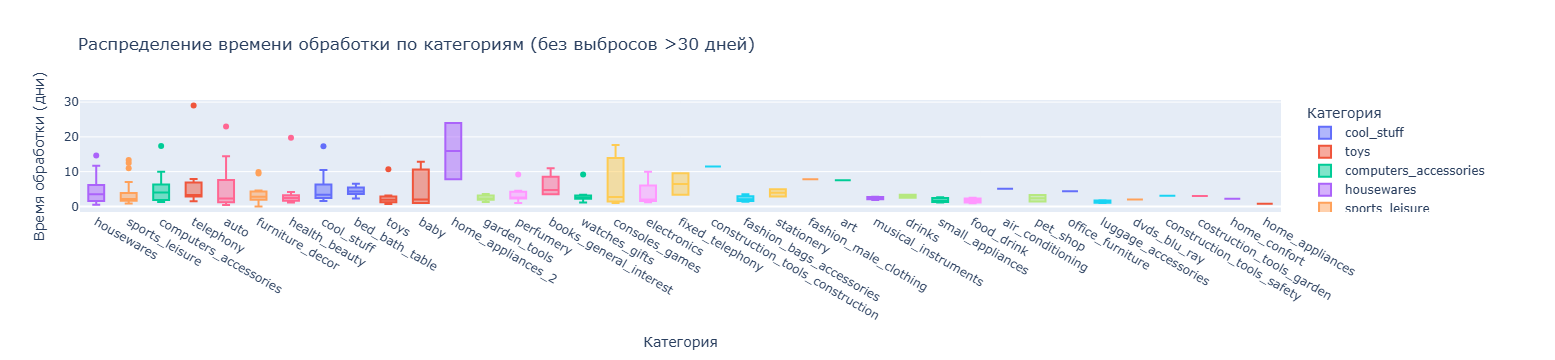

In [209]:
# Убираем выбросы для читаемости (handling_days <= 30)
filtered = seller_metrics[seller_metrics['avg_handling_days'] <= 30].dropna(subset=['avg_handling_days'])

fig = px.box(filtered,
             x='top_category',
             y='avg_handling_days',
             color='top_category',
             title='Распределение времени обработки по категориям (без выбросов >30 дней)',
             labels={'top_category': 'Категория',
                     'avg_handling_days': 'Время обработки (дни)'})
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [ ]:
### География медленных продавцов – среднее время обработки по штатам (взвешенное)
Показывает: где географически находятся самые неэффективные продавцы (H5).

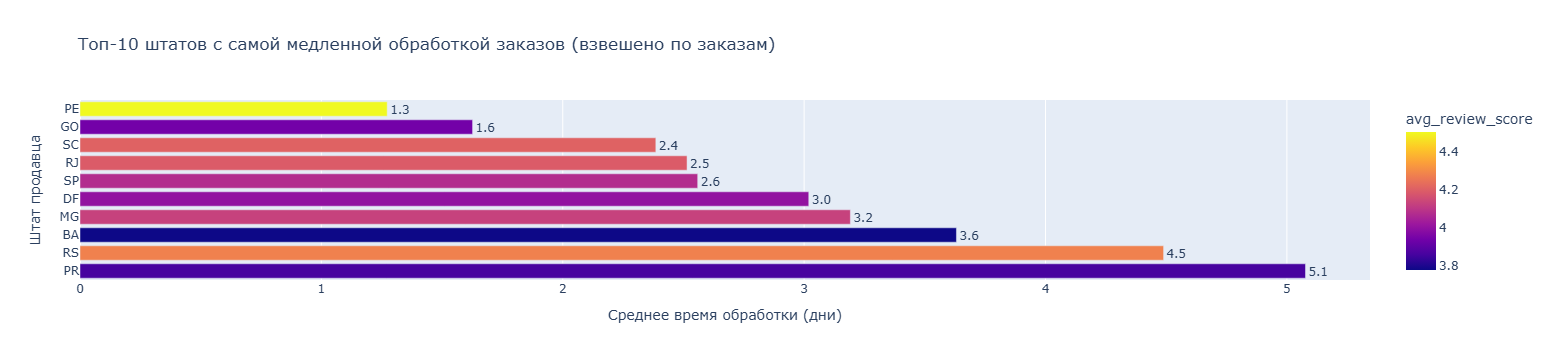

In [211]:
# Сортируем по убыванию
def weighted_mean(x, w): return (x * w).sum() / w.sum()

state_weighted = seller_metrics.groupby('seller_state').apply(
    lambda g: pd.Series({
        'num_sellers': len(g),
        'total_orders': g['total_orders'].sum(),
        'avg_handling_weighted': weighted_mean(g['avg_handling_days'], g['total_orders']),
        'avg_review_score': weighted_mean(g['avg_review_score'], g['total_orders'])
    })
).reset_index()


state_weighted = state_weighted.sort_values('avg_handling_weighted', ascending=False)

fig = px.bar(state_weighted.head(10),
             x='avg_handling_weighted',
             y='seller_state',
             orientation='h',
             color='avg_review_score',
             text='avg_handling_weighted',
             title='Топ-10 штатов с самой медленной обработкой заказов (взвешено по заказам)',
             labels={'avg_handling_weighted': 'Среднее время обработки (дни)',
                     'seller_state': 'Штат продавца'})
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.show()

### Динамика среднего времени обработки по месяцам
Показывает: есть ли тренд (продавцы становятся быстрее/медленнее со временем). 

In [213]:
orders_agg

,order_id,seller_id,order_total_revenue,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,handling_days,transit_days,total_delivery_days,is_late,product_category_name_english,customer_state,seller_state,purchase_year,purchase_month_num,late_days
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,72.19,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,5,6,1,7,False,cool_stuff,RJ,SP,2017,9,-9
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,259.83,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,4,8,8,16,False,pet_shop,SP,SP,2017,4,-3
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,216.87,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,5,1,6,7,False,furniture_decor,MG,MG,2018,1,-14
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,25.78,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,4,2,4,6,False,perfumery,SP,SP,2018,8,-6
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,218.04,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,5,11,13,24,False,garden_tools,SP,PR,2017,2,-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95118,fffc94f6ce00a00581880bf54a75a037,b8bc237ba3788b23da09c0f1f3a3288c,343.4,delivered,2018-04-23 13:57:06,2018-05-10 22:56:40,2018-05-18,5,1,15,16,False,housewares,MA,SC,2018,4,-8
95119,fffcd46ef2263f404302a634eb57f7eb,f3c38ab652836d21de61fb8314b69182,386.53,delivered,2018-07-14 10:26:46,2018-07-23 20:31:55,2018-08-01,5,2,6,8,False,computers_accessories,PR,SP,2018,7,-9
95120,fffce4705a9662cd70adb13d4a31832d,c3cfdc648177fdbbbb35635a37472c53,116.85,delivered,2017-10-23 17:07:56,2017-10-28 12:22:22,2017-11-10,5,2,1,3,False,sports_leisure,SP,PR,2017,10,-13
95121,fffe18544ffabc95dfada21779c9644f,2b3e4a2a3ea8e01938cabda2a3e5cc79,64.71,delivered,2017-08-14 23:02:59,2017-08-16 21:59:40,2017-08-25,5,0,1,1,False,computers_accessories,SP,SP,2017,8,-9


In [212]:
monthly_handling = orders_agg.groupby(['purchase_year', 'purchase_month_num']).agg(
    avg_handling_days = ('handling_days', 'mean'),
    num_orders = ('order_id', 'count')
).reset_index()
monthly_handling['date'] = pd.to_datetime(monthly_handling[['purchase_year', 'purchase_month_num']].assign(day=1))

fig = px.line(monthly_handling,
              x='date',
              y='avg_handling_days',
              title='Динамика среднего времени обработки по месяцам',
              labels={'date': 'Месяц', 'avg_handling_days': 'Среднее время обработки (дни)'},
              markers=True)
fig.add_hline(y=orders_agg['handling_days'].mean(), line_dash="dash", annotation_text="Бенчмарк (все заказы)")
fig.show()

ValueError: to assemble mappings requires at least that [year, month, day] be specified: [month,year] is missing

### Падение оценки из-за просрочки (Review Drop)
Ключевой инсайт для бизнеса: покажите два столбца – оценки вовремя vs просроченных заказов.

In [214]:
# Готовим данные
review_by_lateness = orders_agg.groupby('is_late')['review_score'].mean().reset_index()
review_by_lateness['is_late'] = review_by_lateness['is_late'].map({False: 'Вовремя', True: 'Просрочка'})

fig = px.bar(review_by_lateness,
             x='is_late',
             y='review_score',
             color='is_late',
             text='review_score',
             title=f'Средняя оценка клиента: вовремя vs просрочка (разница = {review_drop:.2f} балла)',
             labels={'is_late': 'Статус доставки', 'review_score': 'Средняя оценка'})
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

TypeError: unsupported format string passed to Series.__format__

### Корреляционная матрица метрик продавца (тепловая карта)
Показывает: взаимосвязи между основными KPI (например, avg_handling_days коррелирует с late_rate – проверка H1).

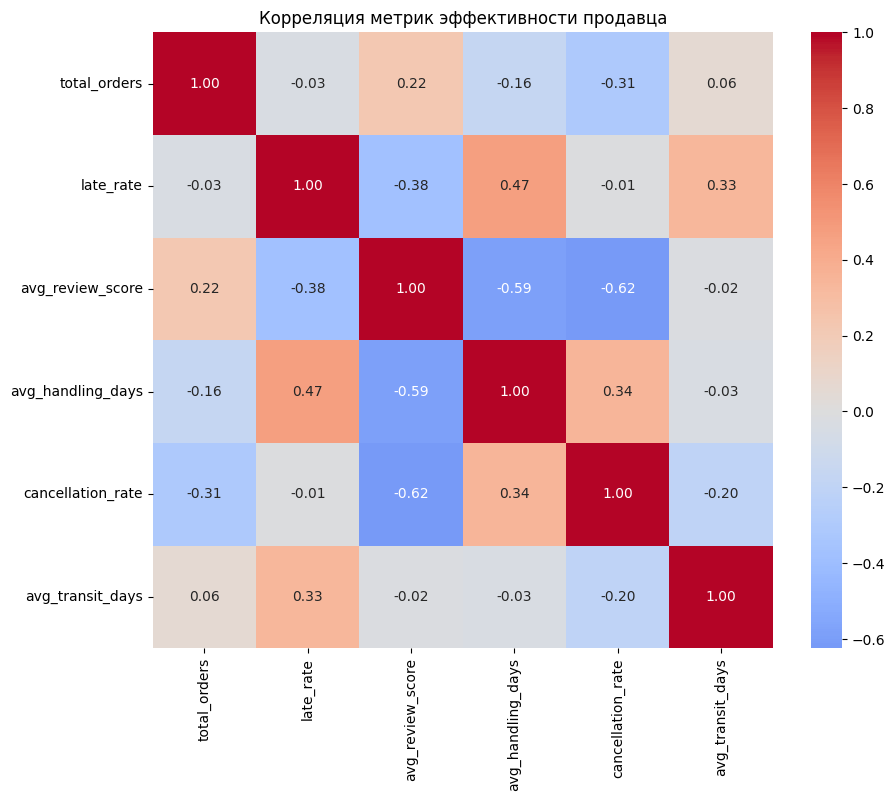

In [215]:
corr_cols = ['total_orders', 'late_rate', 'avg_review_score', 'avg_handling_days',
             'cancellation_rate', 'avg_transit_days']
corr_data = seller_metrics[corr_cols].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляция метрик эффективности продавца')
plt.show()

In [419]:
df = df[df['order_status'] == 'delivered'].copy()

In [420]:
df.shape

(113210, 23)

In [421]:
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113210 entries, 0 to 115608
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113210 non-null  object        
 1   order_status                   113210 non-null  object        
 2   order_purchase_timestamp       113210 non-null  datetime64[ns]
 3   order_approved_at              113196 non-null  datetime64[ns]
 4   order_delivered_carrier_date   113208 non-null  datetime64[ns]
 5   order_delivered_customer_date  113202 non-null  datetime64[ns]
 6   order_estimated_delivery_date  113210 non-null  datetime64[ns]
 7   payment_type                   113210 non-null  object        
 8   payment_value                  113210 non-null  float64       
 9   order_item_id                  113210 non-null  int64         
 10  product_id                     113210 non-null  object        
 11  selle

In [423]:
df[df['order_delivered_customer_date'].isna()]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score
54219,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,credit_card,134.83,1,a50acd33ba7a8da8e9db65094fa990a4,8581055ce74af1daba164fdbd55a40de,2017-12-04 17:56:40,117.3,17.53,auto,13467e882eb3a701826435ee4424f2bd,cerquilho,SP,guarulhos,SP,f48c6c944a5d52dcca8ac5c4ec417cf2,5
83385,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30,credit_card,158.07,1,e7d5464b94c9a5963f7c686fc80145ad,58f1a6197ed863543e0136bdedb3fce2,2018-07-05 17:15:12,139,19.07,watches_gifts,1bd06a0c0df8b23dacfd3725d2dc0bb9,pindamonhangaba,SP,conselheiro lafaiete,MG,25e11638a3d01a87e8e62338a39eee28,5
83393,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30,credit_card,158.07,1,e7d5464b94c9a5963f7c686fc80145ad,58f1a6197ed863543e0136bdedb3fce2,2018-07-05 22:15:14,139,19.07,watches_gifts,3bc508d482a402715be4d5cf4020cc81,sumare,SP,conselheiro lafaiete,MG,bb311d9562ecbefc8e4be756d8999892,5
86329,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,debit_card,354.24,1,2167c8f6252667c0eb9edd51520706a1,0bb738e4d789e63e2267697c42d35a2d,2018-06-26 07:19:05,329,25.24,industry_commerce_and_business,2f17c5b324ad603491521b279a9ff4de,quadra,SP,sao roque,SP,c0dd6bec0375c376f044af102118526f,5
91971,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26,credit_card,120.12,1,a2a7efc985315e86d4f0f705701b342b,ed4acab38528488b65a9a9c603ff024a,2018-06-18 12:30:35,110.99,9.13,computers_accessories,cce5e8188bf42ffb3bb5b18ff58f5965,guarulhos,SP,sao paulo,SP,0d4c56af896dd6eb9de8edbaa1902d22,1
99750,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24,credit_card,204.62,1,ec165cd31c50585786ffda6feff5d0a6,8bdd8e3fd58bafa48af76b2c5fd71974,2018-07-05 21:29:54,188.99,15.63,toys,ebf7e0d43a78c81991a4c59c145c75db,sao carlos,SP,sao paulo,SP,ee2d30652e2f7fc00861074f795f5bf0,5
112695,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23,credit_card,194,1,30b5b5635a79548a48d04162d971848f,f9bbdd976532d50b7816d285a22bd01e,2017-06-04 23:30:16,179,15,sports_leisure,d77cf4be2654aa70ef150f8bfec076a6,porto alegre,RS,sao paulo,SP,4e755f114e50d33b9ac6a56e0d7d3ea9,5
112834,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19,credit_card,54.97,1,55bfa0307d7a46bed72c492259921231,343e716476e3748b069f980efbaa294e,2018-07-03 16:29:30,45.9,9.07,books_general_interest,175378436e2978be55b8f4316bce4811,ribeirao pires,SP,campinas,SP,d055795a562efffefe47ef81e5435322,5


In [424]:
df[df['order_delivered_customer_date'].isna()].head(1)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score
54219,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,credit_card,134.83,1,a50acd33ba7a8da8e9db65094fa990a4,8581055ce74af1daba164fdbd55a40de,2017-12-04 17:56:40,117.3,17.53,auto,13467e882eb3a701826435ee4424f2bd,cerquilho,SP,guarulhos,SP,f48c6c944a5d52dcca8ac5c4ec417cf2,5


Пропуски в approved_at все со статусом оплаты 'boleto'(постоплата). Заполню средним значением с таким же типомо оплаты чтобы не удалятЬ уданные.

In [425]:
# Рассчитываем медиану задержки для boleto
#boleto_delay_median = df[(df['payment_type'] == 'boleto') & (df['order_approved_at'].notna())]['order_approved_at'].sub(df['order_purchase_timestamp']).dt.days.median()

#print(f"Медианная задержка для boleto: {boleto_delay_median:.0f} дней")

In [426]:
df_approved_analysis = df[(df['order_approved_at'].notna()) & (df['order_purchase_timestamp'].notna())].copy()
df_approved_analysis.shape

(113196, 23)

In [427]:
df_approved_analysis['approval_delay_days_int'] = (df_approved_analysis['order_approved_at'] - df_approved_analysis['order_purchase_timestamp']).dt.days
df_approved_analysis['approval_delay_hours'] = (df_approved_analysis['order_approved_at'] - df_approved_analysis['order_purchase_timestamp']).dt.total_seconds() / 3600

In [428]:
payment_analysis = df_approved_analysis.groupby('payment_type').agg({
    'approval_delay_days_int': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'approval_delay_hours': ['mean', 'median']
}).round(2)

display(payment_analysis)

approval_delay_days_int                          approval_delay_hours       
                               count mean median  std min max                 mean median
payment_type                                                                             
boleto                         22015 0.89      1  1.1   0  30                33.16  29.39
credit_card                    83536 0.11      0 0.51   0  30                 4.59   0.27
debit_card                      1623 0.19      0 0.93   0  13                 8.98   0.85
voucher                         6022 0.23      0  0.7   0  11                 8.79   0.28

In [429]:
delay_minutes = 1990   # 33 часа 10 минут = 33*60 + 10 = 1990 минут
mask_boleto = (df['payment_type'] == 'boleto') & (df['order_approved_at'].isna())
df.loc[mask_boleto, 'order_approved_at'] = (df.loc[mask_boleto, 'order_purchase_timestamp'] +  pd.Timedelta(minutes=delay_minutes))

По nan значениям в order_delivered_carrier_date и order_delivered_customer_date - удаляю строки, т.к. их незначительное кол-во

In [430]:
df = df.dropna(subset=['order_delivered_carrier_date', 'order_delivered_customer_date'])

In [431]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113201 entries, 0 to 115608
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113201 non-null  object        
 1   order_status                   113201 non-null  object        
 2   order_purchase_timestamp       113201 non-null  datetime64[ns]
 3   order_approved_at              113201 non-null  datetime64[ns]
 4   order_delivered_carrier_date   113201 non-null  datetime64[ns]
 5   order_delivered_customer_date  113201 non-null  datetime64[ns]
 6   order_estimated_delivery_date  113201 non-null  datetime64[ns]
 7   payment_type                   113201 non-null  object        
 8   payment_value                  113201 non-null  float64       
 9   order_item_id                  113201 non-null  int64         
 10  product_id                     113201 non-null  object        
 11  selle

In [432]:
# Создаём временные признаки для аналитики
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_month_num'] = df['order_purchase_timestamp'].dt.month

In [433]:
df['purchase_year'].unique()

array([2017, 2018, 2016], dtype=int32)

In [434]:
df_unique = df['purchase_month'].drop_duplicates().sort_values().to_frame(name='unique_dates')
print(df_unique)

      unique_dates
2691       2016-10
64803      2016-12
2105       2017-01
81         2017-02
102        2017-03
70         2017-04
75         2017-05
79         2017-06
19         2017-07
3          2017-08
8          2017-09
0          2017-10
12         2017-11
108        2017-12
112        2018-01
125        2018-02
149        2018-03
127        2018-04
152        2018-05
128        2018-06
166        2018-07
154        2018-08


In [435]:
df.sample(3)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score,purchase_month,purchase_year,purchase_month_num
14033,16f2b04292cfdf925c7d231f98812249,delivered,2017-09-30 11:48:22,2017-09-30 12:04:21,2017-10-02 16:28:18,2017-10-09 17:33:50,2017-10-31,credit_card,190.37,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2017-10-05 12:04:21,149.99,40.38,computers_accessories,370c2f5564234be2fa99ce15c1e8c962,gastao vidigal,SP,ilicinea,MG,4aac8633b321666c0c4109b24fa09d96,4,2017-09,2017,9
57117,2a206d4997fedfb60455f2a06ae3028a,delivered,2018-06-28 15:18:00,2018-06-29 02:53:15,2018-06-29 12:02:00,2018-07-10 19:43:11,2018-07-19,boleto,73.92,1,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-07-03 02:53:15,19.89,17.07,electronics,0283917cf6822284c4341224ef003fb6,campo grande,MS,brasilia,DF,97cd92cc53033431068eef4e4d7197e5,4,2018-06,2018,6
63699,f9d71ca22c3574cb50bd404950d12ff3,delivered,2017-05-14 14:59:05,2017-05-14 15:10:15,2017-05-15 10:17:06,2017-05-23 10:34:57,2017-06-09,credit_card,120.2,1,a49969155f3a64afc931fd281444b2b6,f63d8f293af3a6454377546bd9dd19ff,2017-05-18 15:10:15,43.99,16.11,auto,3dadc7103d20bae9a1d9e0ade0314b5e,araruama,RJ,votorantim,SP,3e428683cd7d88fd51df63a51964ea8f,5,2017-05,2017,5


In [436]:
# Полное время выполнения заказа от момента оформления до момента получения клиентом:
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
print(f"Среднее время доставки: {df['delivery_days'].mean():.1f} дней")

Среднее время доставки: 12.0 дней


In [437]:
# Время обработки заказ продавцом:
df['processing_days'] = (df['order_delivered_carrier_date'] - df['order_purchase_timestamp']).dt.days

In [438]:
# Время транспортировки (сколько заказ находится в пути):
df['shipping_days'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

In [439]:
df[df['order_item_id']  > 1 ]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score,purchase_month,purchase_year,purchase_month_num,delivery_days,processing_days,shipping_days
6,5f49f31e537f8f1a496454b48edbe34d,delivered,2017-08-24 11:31:28,2017-08-24 11:45:25,2017-08-25 14:17:55,2017-08-28 20:12:20,2017-09-14,credit_card,127.45,2,be03d93320192443b8fa24c0ca6ead98,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-30 11:45:25,46.8,67.7,housewares,7a1de9bde89aedca8c5fbad489c5571c,sao paulo,SP,maua,SP,8899ca945efd951c97107b4966289227,1,2017-08,2017,8,4,1,3
69,343e0513a040565d012874605c433ca4,delivered,2017-08-27 19:35:52,2017-08-27 19:50:10,2017-08-29 19:37:43,2017-09-05 20:41:41,2017-09-19,credit_card,135.18,2,2fcef9efef474266c020ab6ccf2c61a8,f5f46307a4d15880ca14fab4ad9dfc9b,2017-08-31 19:50:10,49.99,17.6,sports_leisure,766b303e0dadc92d997f5253e541efbb,franca,SP,rio do sul,SC,a8510246f3188cde739a2df37048c75c,3,2017-08,2017,8,9,2,7
71,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,2,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
72,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,3,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
73,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,4,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115567,161f105f25baba98c7604aad9b99d9a6,delivered,2018-03-14 12:26:50,2018-03-14 13:08:17,2018-03-14 23:58:47,2018-03-15 15:56:23,2018-03-26,credit_card,170.6,2,7515ab3fc02c8f43b07e9451497fb13e,bc2ac6b95e1accce9858528ee566c17e,2018-03-20 13:08:17,77,8.3,books_imported,0cd9db48a316e0dec783953edc621f44,sao paulo,SP,campinas,SP,dcf50b04b27040e4470112c1034cd33e,5,2018-03,2018,3,1,0,0
115569,fb044859ae3cc0721c694443c343aed4,delivered,2017-11-03 20:25:39,2017-11-03 21:31:22,2017-11-06 21:29:04,2017-11-07 18:04:58,2017-11-16,credit_card,188.92,2,f4c6e3643d47244bec4766d72c07ac4f,bc2ac6b95e1accce9858528ee566c17e,2017-11-09 20:35:27,109,11.89,books_imported,83b82ec5bf93a47ccfbe05452ea32009,jaguariuna,SP,campinas,SP,125688543cfedd2742b1cc01dfb36b97,5,2017-11,2017,11,3,3,0
115578,9ea64f21920bb6b6972cadb024eabee6,delivered,2018-07-02 15:30:15,2018-07-05 16:18:56,2018-07-06 08:41:00,2018-07-16 13:56:21,2018-07-23,boleto,166.73,2,68ad45d48d69404aeb71ce87e1b2c948,7c5b05cbdb5542049f38d90d7815b97d,2018-07-09 08:32:25,59.89,13.74,books_imported,b33bcd190054cfb026a0c0f8a2a2b18c,guaratingueta,SP,sao paulo,SP,d4372ecfa254c9ab3c176a47768fe93c,5,2018-07,2018,7,13,3,10
115596,872b07190c0c9c0f13475d2141c4036a,delivered,2018-07-03 10:10:12,2018-07-05 16:22:38,2018-07-03 12:00:00,2018-07-10 17:18:49,2018-08-02,credit_card,168.72,2,97de49733ccaac64d122444d8db709d1,7c5b05cbdb5542049f38d90d7815b97d,2018-07-06 10:30:56,64.99,19.37,books_imported,c5df80808db02b2e08abd92b9d964b9b,belem,PA,sao paulo,SP,cf0946ded1412516d307ee5ed2743fff,

In [440]:
df[df['order_id'] == '82bce245b1c9148f8d19a55b9ff70644']

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_unique_id,customer_city,customer_state,seller_city,seller_state,review_id,review_score,purchase_month,purchase_year,purchase_month_num,delivery_days,processing_days,shipping_days
70,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,1,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
71,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,2,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
72,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,3,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
73,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,4,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15
74,82bce245b1c9148f8d19a55b9ff70644,delivered,2017-04-20 17:15:46,2017-04-21 05:15:56,2017-04-24 09:34:13,2017-05-10 09:17:55,2017-05-12,boleto,267.8,5,a5a0e71a81ae65aa335e71c06261e260,c8417879a15366a17c30af34c798c332,2017-04-27 05:15:56,38,15.56,housewares,f9effeed3df9ae063a58c0759b96f8b2,cascavel,PR,sao paulo,SP,fd793fea4f4a2ddcc956561144b6c04e,1,2017-04,2017,4,19,3,15


In [441]:
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = df['delay_days'] > 0
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [442]:
print(f"Среднее время доставки: {df['delivery_days'].mean():.1f} дней")
print(f"Доля задержек достаки: {(df['is_delayed'].mean() * 100):.1f}%")
print(f"Средняя оценка: {df['review_score'].mean():.1f}")

Среднее время доставки: 12.0 дней
Доля задержек достаки: 6.4%
Средняя оценка: 4.1


In [443]:
df.shape

(113201, 31)

In [444]:
# Насколько продавец нарушил сроки отправки - Преобразую отрицательные значения(не нарушил сроки отгрузки) в 0, а положительные так и оставляю:
df['seller_shipping_late_days'] = (df['order_delivered_carrier_date'] - df['shipping_limit_date']).dt.days.clip(lower=0)
# Создаю бинарный флаг - нарушил/не нарушил сроки отгрузки товара
df['seller_delayed'] = df['seller_shipping_late_days'] > 0
# Время от подтверждения заказа до дедлайна (сколько времени ДАНО продавцу)
df['seller_allowed_time_days'] = (df['shipping_limit_date'] - df['order_approved_at']).dt.days
# Время от дедлайна до фактической отгрузки (если опоздал)
df['seller_overdue_days'] = df['seller_shipping_late_days'].clip(lower=0)

In [445]:
# 1. Находим все заказы с несколькими продавцами
orders_with_multiple_sellers = df.groupby('order_id')['seller_id'].nunique()
orders_with_multiple_sellers = orders_with_multiple_sellers[orders_with_multiple_sellers > 1]

print("="*60)
print("АНАЛИЗ ЗАКАЗОВ С НЕСКОЛЬКИМИ ПРОДАВЦАМИ")
print("="*60)

print(f"\nВсего заказов: {df['order_id'].nunique():,}")
print(f"Заказов с >1 продавцом: {len(orders_with_multiple_sellers):,}")
print(f"Доля: {len(orders_with_multiple_sellers) / df['order_id'].nunique() * 100:.2f}%")

if len(orders_with_multiple_sellers) == 0:
    print("\nВ ДАННЫХ НЕТ ЗАКАЗОВ С НЕСКОЛЬКИМИ ПРОДАВЦАМИ")
    print("→ Все заказы имеют только одного продавца")
    print("→ Поэтому 'first' и 'max' дают одинаковый результат")

АНАЛИЗ ЗАКАЗОВ С НЕСКОЛЬКИМИ ПРОДАВЦАМИ

Всего заказов: 94,479
Заказов с >1 продавцом: 1,233
Доля: 1.31%


In [446]:
# 2. Для каждого заказа с несколькими продавцами проверяем значения seller_delayed
analysis_results = []
    
for order_id in orders_with_multiple_sellers.index:
    order_data = df[df['order_id'] == order_id]
        
        # Получаем уникальные значения seller_dealyed
    delay_values = order_data['seller_delayed'].unique()
        
        # Получаем информацию по каждому продавцу
    sellers_info = order_data.groupby('seller_id').agg({
            'seller_delayed': 'first',
            'order_item_id': 'count'
    }).reset_index()
        
    analysis_results.append({
            'order_id': order_id,
            'num_sellers': len(sellers_info),
            'num_items': len(order_data),
            'delay_values': delay_values,
            'all_same': len(delay_values) == 1,
            'has_true': True in delay_values,
            'has_false': False in delay_values,
            'sellers': sellers_info['seller_id'].tolist(),
            'delay_status': sellers_info['seller_delayed'].tolist()
        })

In [447]:
   # 3. Считаем статистику
results_df = pd.DataFrame(analysis_results)
    
print("\n" + "="*60)
print("СТАТИСТИКА ПО НАРУШЕНИЯМ")
print("="*60)
    
same_delay = results_df['all_same'].sum()
different_delay = (~results_df['all_same']).sum()
    
print(f"\nЗаказы, где ВСЕ продавцы имеют ОДИНАКОВЫЙ флаг нарушения: {same_delay} ({same_delay/len(results_df)*100:.1f}%)")
print(f"Заказы, где продавцы имеют РАЗНЫЕ флаги нарушения: {different_delay} ({different_delay/len(results_df)*100:.1f}%)")


СТАТИСТИКА ПО НАРУШЕНИЯМ

Заказы, где ВСЕ продавцы имеют ОДИНАКОВЫЙ флаг нарушения: 1229 (99.7%)
Заказы, где продавцы имеют РАЗНЫЕ флаги нарушения: 4 (0.3%)


In [448]:
# 1. Фильтруем заказы с разными флагами
different_delay_orders = results_df[~results_df['all_same']].copy()

print("="*70)
print(f"🔍 ВСЕ ЗАКАЗЫ С РАЗНЫМИ ФЛАГАМИ НАРУШЕНИЙ (НАЙДЕНО: {len(different_delay_orders)})")
print("="*70)

# 2. Детальный вывод каждого заказа
for idx, row in different_delay_orders.iterrows():
    print(f"\n{'='*70}")
    print(f"📦 ЗАКАЗ №{idx+1}: {row['order_id']}")
    print(f"{'='*70}")
    print(f"  📊 Количество продавцов: {row['num_sellers']}")
    print(f"  📦 Количество товаров: {row['num_items']}")
    print(f"  🚩 Флаги нарушений: {row['delay_status']}")
    print(f"  ✅ Все флаги одинаковы: {row['all_same']}")
    print(f"  🔴 Есть нарушители (True): {row['has_true']}")
    print(f"  🟢 Есть соблюдающие (False): {row['has_false']}")
    
    # Детально по каждому продавцу
    print(f"\n  👨‍💼 ДЕТАЛИ ПО ПРОДАВЦАМ:")
    for i, (seller, breach) in enumerate(zip(row['sellers'], row['delay_status']), 1):
        print(f"    Продавец {i}: {seller}")
        print(f"      - Нарушил SLA: {breach}")
        
        # Получаем дополнительную информацию о продавце
        seller_data = df[(df['order_id'] == row['order_id']) & (df['seller_id'] == seller)].iloc[0]
        print(f"      - Штат продавца: {seller_data['seller_state']}")
        print(f"      - Штат покупателя: {seller_data['customer_state']}")
        print(f"      - Категория товара: {seller_data['product_category_name_english']}")
        print(f"      - Опоздание продавца: {seller_data['seller_shipping_late_days']} дней")
    
    # Показываем все товары в заказе
    print(f"\n  ВСЕ ТОВАРЫ В ЗАКАЗЕ:")
    order_items = df[df['order_id'] == row['order_id']]
    for _, item in order_items.iterrows():
        print(f"    Товар {item['order_item_id']}: seller={item['seller_id'][:30]}..., "
              f"категория={item['product_category_name_english']}, "
              f"нарушил={item['seller_delayed']}")

print("\n" + "="*70)
print("ВЛИЯНИЕ НА АГРЕГАЦИЮ")
print("="*70)

# 3. Анализируем, как разные флаги влияют на агрегацию
for idx, row in different_breach_orders.iterrows():
    order_data = df[df['order_id'] == row['order_id']]
    
    first_result = order_data['seller_delayed'].iloc[0]
    max_result = order_data['seller_delayed'].max()
    min_result = order_data['seller_delayed'].min()
    any_result = order_data['seller_delayed'].any()  # то же что и max
    
    print(f"\nЗаказ: {row['order_id']}")
    print(f"  Значения seller_breached_sla: {order_data['seller_delayed'].tolist()}")
    print(f"  first() → {first_result}")
    print(f"  max()   → {max_result}")
    print(f"  min()   → {min_result}")
    
    if first_result != max_result:
        print(f"  РАЗНИЦА! first={first_result}, max={max_result}")
        print(f"  → Рекомендуется использовать max() для корректной бизнес-логики")


🔍 ВСЕ ЗАКАЗЫ С РАЗНЫМИ ФЛАГАМИ НАРУШЕНИЙ (НАЙДЕНО: 4)

📦 ЗАКАЗ №885: b866af202be0692766081310cd4085e1
  📊 Количество продавцов: 2
  📦 Количество товаров: 2
  🚩 Флаги нарушений: [False, True]
  ✅ Все флаги одинаковы: False
  🔴 Есть нарушители (True): True
  🟢 Есть соблюдающие (False): True

  👨‍💼 ДЕТАЛИ ПО ПРОДАВЦАМ:
    Продавец 1: 0b09101900100c0e9d312861fad5a1b9
      - Нарушил SLA: False
      - Штат продавца: SP
      - Штат покупателя: SP
      - Категория товара: furniture_decor
      - Опоздание продавца: 0 дней
    Продавец 2: 41b39e28db005d9731d9d485a83b4c38
      - Нарушил SLA: True
      - Штат продавца: SP
      - Штат покупателя: SP
      - Категория товара: bed_bath_table
      - Опоздание продавца: 4 дней

  ВСЕ ТОВАРЫ В ЗАКАЗЕ:
    Товар 1: seller=41b39e28db005d9731d9d485a83b4c..., категория=bed_bath_table, нарушил=True
    Товар 2: seller=0b09101900100c0e9d312861fad5a1..., категория=furniture_decor, нарушил=False

📦 ЗАКАЗ №914: bda46920fb31dc59b147208200b18377
  📊 Коли

Так как заказов где один продавец нарушил сроки отгрузки товара, а другой нет - очень мало - всего 4 заказа (0,03%) от всех данных - это не критично, выделю данные заказы в отдельную витрину чтобы было понимание что такие есть

In [449]:
different_delay_orders

,order_id,num_sellers,num_items,delay_values,all_same,has_true,has_false,sellers,delay_status
884,b866af202be0692766081310cd4085e1,2,2,"[True, False]",False,True,True,"[0b09101900100c0e9d312861fad5a1b9, 41b39e28db005d9731d9d485a83b4c38]","[False, True]"
913,bda46920fb31dc59b147208200b18377,2,2,"[False, True]",False,True,True,"[81783131d2a97c8d44d406a4be81b5d9, b2ba3715d723d245138f291a6fe42594]","[True, False]"
929,c161187ab4f2133d752f8a028b51f74e,2,2,"[True, False]",False,True,True,"[0241d4d5d36f10f80c644447315af0bd, c31eff8334d6b3047ed34bebd4d62c36]","[True, False]"
1012,d12750a4a29395c6d1cd3a83992f1e16,2,2,"[True, False]",False,True,True,"[1c68394e931a64f90ea236c5ea590300, 88460e8ebdecbfecb5f9601833981930]","[True, False]"


In [450]:
different_delay_orders.to_csv(f'{PREPROCESSING_DIR}/different_delay_orders.csv', index=False)
print(f"\nСохранено: {PREPROCESSING_DIR}/different_delay_orders.csv")


Сохранено: /home/alorozhkov/jup/dashbords/dash_1/preprocessing/different_delay_orders.csv


In [451]:
# Удаляю из основной таблицы заказы с несколькими продавцами и разными статусами по отгрузке:
delay_orders = ['b866af202be0692766081310cd4085e1', 'bda46920fb31dc59b147208200b18377', 'c161187ab4f2133d752f8a028b51f74e', 'd12750a4a29395c6d1cd3a83992f1e16']

# Находим индексы
idx_to_drop = df[df['order_id'].isin(delay_orders)].index
print(f'Найдено {len(idx_to_drop)} строк для удаления')

df.drop(idx_to_drop, inplace=True)

# Проверяем, что этих order_id больше нет
remaining = df[df['order_id'].isin(delay_orders)]
print(f'Осталось проблемных заказов: {len(remaining)}')

Найдено 8 строк для удаления
Осталось проблемных заказов: 0


In [452]:
df.shape

(113193, 35)

In [453]:
unique_orders = df.groupby('order_id').agg({
    'payment_value': 'first',           # общая сумма заказа
    'review_score': 'first',            # оценка заказа
    'is_delayed': 'first',              # была ли просрочка
    'delay_days': 'first',              # дни просрочки
    'delivery_days': 'first',           # общее время доставки
    'seller_delayed': 'max', #True если хоть один продавец нарушил
    'seller_shipping_late_days': 'max',  # максимальное опоздание
    'order_purchase_timestamp': 'first', # дата заказа
    'order_approved_at': 'first', # дата подтверждения заказ
    'order_delivered_carrier_date': 'first', # когда передан в доставку ТК
    'order_delivered_customer_date': 'first', # доставлен покупателю
    'order_estimated_delivery_date': 'first', # дата предполагаемой доставки
    'seller_state': 'first', # город отправки
    'customer_state': 'first', # ород получения
    'purchase_month': 'first',
    'purchase_year': 'first',
    'purchase_month_num': 'first',
    'seller_allowed_time_days': 'max',
    'seller_overdue_days': 'max'
}).reset_index()

In [454]:
# KPI на уровне ЗАКАЗОВ
kpi_dashboard= pd.DataFrame({
    'metric_name': [
        'Total Revenue',
        'Average Order Value (AOV)',
        'Average Review Score',
        'Delay Delivery Rate',
        'Average Delivery Days',
        'Seller Delay Rate',
        'Critical Reviews Rate (1-2★)',
        'Total Orders',
        'Unique Customers',
        'Unique Sellers'
    ],
    'metric_value': [
        unique_orders['payment_value'].sum(),
        unique_orders['payment_value'].mean(),
        unique_orders['review_score'].mean(),
        (unique_orders['is_delayed'].sum() / len(unique_orders)) * 100,
        unique_orders['delivery_days'].mean(),
        (unique_orders['seller_delayed'].sum() / len(unique_orders)) * 100,
        (unique_orders['review_score'] <= 2).mean() * 100, len(unique_orders),
        df['customer_unique_id'].nunique(),
        df['seller_id'].nunique()
    ]
})


In [455]:
kpi_dashboard

,metric_name,metric_value
0,Total Revenue,14848657.36999999918
1,Average Order Value (AOV),157.170228843609
2,Average Review Score,4.157798359354
3,Delay Delivery Rate,6.651495104525
4,Average Delivery Days,12.048753638529
5,Seller Delay Rate,4.444562053453
6,Critical Reviews Rate (1-2★),12.752580047632
7,Total Orders,94475
8,Unique Customers,91469
9,Unique Sellers,2906


In [458]:
def format_metric(row):
    val = row['metric_value']
    name = row['metric_name']
    if name == 'Total Revenue':
        return f"{val:,.0f}".replace(',', ' ')  # пробелы как разделители
    elif name in ['Total Orders', 'Unique Customers', 'Unique Sellers']:
        return f"{int(val):,}".replace(',', ' ')
    elif name in ['Average Order Value (AOV)', 'Average Review Score']:
        return f"{val:.2f}"
    else:
        return f"{val:.1f}"

kpi_dashboard['formatted_value'] = kpi_dashboard.apply(format_metric, axis=1)
print(kpi_dashboard[['metric_name', 'formatted_value']])

                    metric_name formatted_value
0                 Total Revenue      14 848 657
1     Average Order Value (AOV)          157.17
2          Average Review Score            4.16
3           Delay Delivery Rate             6.7
4         Average Delivery Days            12.0
5             Seller Delay Rate             4.4
6  Critical Reviews Rate (1-2★)            12.8
7                  Total Orders          94 475
8              Unique Customers          91 469
9                Unique Sellers           2 906


In [459]:
kpi_dashboard

,metric_name,metric_value,formatted_value
0,Total Revenue,14848657.36999999918,14 848 657
1,Average Order Value (AOV),157.170228843609,157.17
2,Average Review Score,4.157798359354,4.16
3,Delay Delivery Rate,6.651495104525,6.7
4,Average Delivery Days,12.048753638529,12.0
5,Seller Delay Rate,4.444562053453,4.4
6,Critical Reviews Rate (1-2★),12.752580047632,12.8
7,Total Orders,94475,94 475
8,Unique Customers,91469,91 469
9,Unique Sellers,2906,2 906


In [460]:
kpi_dashboard.to_csv(f'{PREPROCESSING_DIR}/kpi_dashboard.csv', index=False)
print(f"\nСохранено: {PREPROCESSING_DIR}/kpi_dashboard.csv")


Сохранено: /home/alorozhkov/jup/dashbords/dash_1/preprocessing/kpi_dashboard.csv


1. Выявить продавцов, которые систематически срывают сроки отгрузки (delay breach rate)
2. Оценить, как задержка продавца влияет на итоговую оценку клиента (review_score)
3. Сравнить эффективность продавцов по категориям товаров и регионам
4. Определить, какая доля просрочек доставки связана именно с продавцом, а не с логистикой
5. Найти продавцов с аномально высокой долей отмен или задержек для точечных проверок
6. Построить рейтинг надёжных продавцов для программы лояльности или приоритетного показа

In [369]:
unique_seller_orders = df.groupby(['order_id', 'seller_id']).agg({
    'seller_delayed': 'first',
    'seller_shipping_late_days': 'first',
    'review_score': 'first',
    'payment_value': 'first',
    'price': 'sum',
    'freight_value': 'sum',
    'seller_state': 'first'
}).reset_index()

# Рассчитываем метрики
seller_delayed_analysis = unique_seller_orders.groupby('seller_id').agg({
    # Основные метрики
    'seller_delayed': ['mean', 'sum', 'count'],  # доля, количество нарушений, всего заказов
    'seller_shipping_late_days': 'mean',
    'review_score': 'mean',
    'payment_value': 'sum'
}).round(3)

# Упрощаем мультииндекс
seller_delayed_analysis.columns = [
    'delay_rate', 'delay_count', 'total_orders',
    'avg_late_days', 'avg_review_score', 'total_revenue'
]

# Добавляем проценты
seller_delayed_analysis['delay_rate_pct'] = seller_delayed_analysis['delay_rate'] * 100
seller_delayed_analysis['compliance_rate_pct'] = 100 - seller_delayed_analysis['delay_rate_pct']
# Фильтруем продавцов с >5 заказами
seller_delayed_analysis = seller_delayed_analysis[seller_delayed_analysis['total_orders'] >= 5]

# Сортируем по доле нарушений
seller_delayed_analysis = seller_delayed_analysis.sort_values('delay_rate_pct', ascending=False)


print("\n" + "="*70)
print("ТОП-10 ПРОБЛЕМНЫХ ПРОДАВЦОВ (по доле нарушений)")
print("="*70)
print(seller_delayed_analysis.head(10)[['delay_rate_pct', 'delay_count', 'total_orders', 
                                        'avg_late_days', 'avg_review_score', 'total_revenue']])


ТОП-10 ПРОБЛЕМНЫХ ПРОДАВЦОВ (по доле нарушений)
                                  delay_rate_pct  delay_count  total_orders  avg_late_days  avg_review_score      total_revenue
seller_id                                                                                                                      
6cf476a4ca74498db55cbccdaa9dcfb6             100            5             5           13.6               3.4              791.6
38874e327ce94d11390b96eb42d61928             100            6             6          8.667                 4            4158.43
48efc9d94a9834137efd9ea76b065a38            84.8           28            33          1.667                 5                666
633ecdf879b94b5337cca303328e4a25              80            4             5            7.6               1.8            1000.07
02d35243ea2e497335cd0f076b45675d            78.6           11            14          4.643             2.643            7216.21
9539213aa8e023c01937bef95dc006da            77.8       

In [370]:
chronic_delayers  = seller_delayed_analysis[seller_delayed_analysis['delay_rate'] > 0.5].sort_values('delay_rate', ascending=False)
chronic_delayers

,delay_rate,delay_count,total_orders,avg_late_days,avg_review_score,total_revenue,delay_rate_pct,compliance_rate_pct
seller_id,,,,,,,,
6cf476a4ca74498db55cbccdaa9dcfb6,1,5,5,13.6,3.4,791.6,100,0
38874e327ce94d11390b96eb42d61928,1,6,6,8.667,4,4158.43,100,0
48efc9d94a9834137efd9ea76b065a38,0.848,28,33,1.667,5,666,84.8,15.2
633ecdf879b94b5337cca303328e4a25,0.8,4,5,7.6,1.8,1000.07,80,20
02d35243ea2e497335cd0f076b45675d,0.786,11,14,4.643,2.643,7216.21,78.6,21.4
9539213aa8e023c01937bef95dc006da,0.778,7,9,2.111,4.556,274.49,77.8,22.2
973f21788dfab357250f69a8dcb7ddee,0.778,7,9,6.111,2.111,1369.35,77.8,22.2
538caafddff204241cecbf3a02e6b3cf,0.75,6,8,7.125,2.75,218.81,75,25
b1b3948701c5c72445495bd161b83a4c,0.714,10,14,9.857,1.929,21924.25,71.4,28.6


Бизнес-инсайт: Эти продавцы требуют немедленного вмешательства – штрафы, обучение или отключение от маркетплейса.

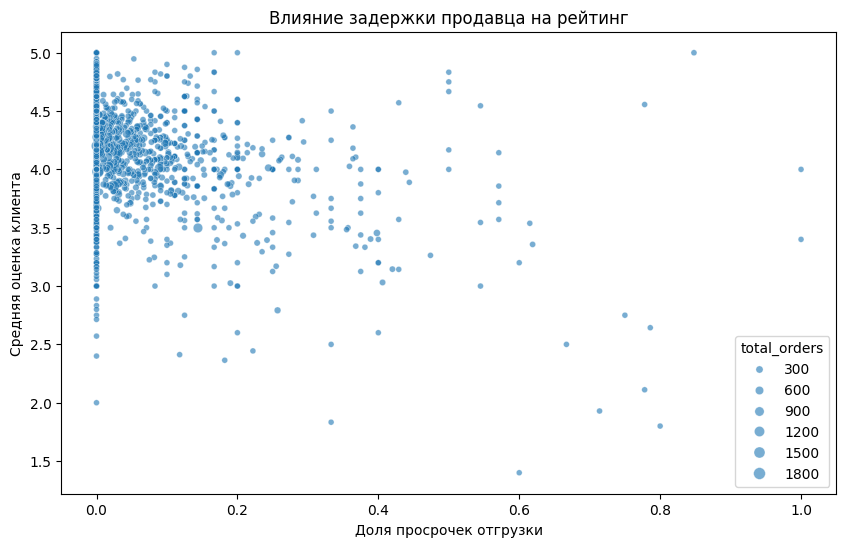

Корреляция между delay_rate и avg_review_score: -0.38


In [371]:
# Scatter plot с размером точки = total_orders
plt.figure(figsize=(10,6))
sns.scatterplot(data=seller_delayed_analysis, 
                x='delay_rate', y='avg_review_score', 
                size='total_orders', alpha=0.6)
plt.xlabel('Доля просрочек отгрузки')
plt.ylabel('Средняя оценка клиента')
plt.title('Влияние задержки продавца на рейтинг')
plt.show()

# Корреляция
corr = seller_delayed_analysis['delay_rate'].corr(seller_delayed_analysis['avg_review_score'])
print(f"Корреляция между delay_rate и avg_review_score: {corr:.2f}")

Бизнес-инсайт: Отрицательная корреляция подтвердит, что задержки продавцов снижают лояльность. Можно количественно оценить потерю баллов при росте просрочек.

In [372]:
# Получаем уникальные пары seller_id + product_category + seller_state
seller_meta = df.groupby('seller_id').agg({
    'seller_state': 'first',
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
}).reset_index()

# Присоединяем метаданные к аналитике
seller_with_cat_region = seller_delayed_analysis.merge(seller_meta, on='seller_id', how='left')

# Теперь можно группировать по категориям
category_analysis = seller_with_cat_region.groupby('product_category_name_english').agg(
    avg_delay_rate=('delay_rate', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_sellers=('seller_id', 'count')
).reset_index().sort_values('avg_delay_rate', ascending=False)

print("Категории с самыми недисциплинированными продавцами:")
print(category_analysis.head(10))

# По регионам (штатам продавцов)
region_analysis = seller_with_cat_region.groupby('seller_state').agg(
    avg_delay_rate=('delay_rate', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_sellers=('seller_id', 'count')
).reset_index().sort_values('avg_delay_rate', ascending=False)

print("\nШтаты с самыми проблемными продавцами:")
display(region_analysis.head(10))

Категории с самыми недисциплинированными продавцами:
   product_category_name_english  avg_delay_rate     avg_review  total_sellers
30       fashion_underwear_beach          0.2508         4.0846              5
1               air_conditioning  0.209142857143 3.725571428571              7
51              office_furniture  0.192166666667 3.770333333333             12
27         fashion_male_clothing          0.1775          4.142              2
29                 fashion_sport            0.13          4.304              1
12                    cine_photo          0.1155          4.226              2
34             furniture_bedroom          0.1144         3.6336              5
31               fixed_telephony  0.113857142857 3.984428571429              7
42             home_construction          0.1127         4.0259             10
15                consoles_games       0.1005625      4.0994375             16

Штаты с самыми проблемными продавцами:


,seller_state,avg_delay_rate,avg_review,total_sellers
15,RN,0.262,4.126333333333,3
5,MA,0.244,4.013,1
1,CE,0.1372,4.2904,5
9,PA,0.125,4.5,1
10,PB,0.119,3.916666666667,3
2,DF,0.076285714286,4.242476190476,21
17,RS,0.066303571429,4.2145,56
13,PR,0.060430851064,4.235255319149,188
7,MS,0.06025,4.35975,4
6,MG,0.057829787234,4.20314893617,141


Бизнес-инсайт: Можно выявить, какие категории или регионы требуют особого внимания (например, продавцы из удалённых штатов чаще опаздывают).

In [473]:
seller_delayed_analysis.to_csv(f'{PREPROCESSING_DIR}/seller_metrics.csv', index=False)
print(f"\nСохранено: {PREPROCESSING_DIR}/seller_metrics.csv")


Сохранено: /home/alorozhkov/jup/dashbords/dash_1/preprocessing/seller_metrics.csv


In [469]:
seller_delayed_analysis = seller_delayed_analysis.reset_index()

In [470]:
print(seller_delayed_analysis.index[:5])

RangeIndex(start=0, stop=5, step=1)


In [474]:
seller_delayed_analysis

,seller_id,delay_rate,delay_count,total_orders,avg_late_days,avg_review_score,total_revenue,delay_rate_pct,compliance_rate_pct
0,6cf476a4ca74498db55cbccdaa9dcfb6,1,5,5,13.6,3.4,791.6,100,0
1,38874e327ce94d11390b96eb42d61928,1,6,6,8.667,4,4158.43,100,0
2,48efc9d94a9834137efd9ea76b065a38,0.848,28,33,1.667,5,666,84.8,15.2
3,633ecdf879b94b5337cca303328e4a25,0.8,4,5,7.6,1.8,1000.07,80,20
4,02d35243ea2e497335cd0f076b45675d,0.786,11,14,4.643,2.643,7216.21,78.6,21.4
...,...,...,...,...,...,...,...,...,...
1721,81f89e42267213cb94da7ddc301651da,0,0,46,0,3.674,4768.97,0,100
1722,8185694b58b2ba6de20fd41ae608bbea,0,0,8,0,4.5,1602.57,0,100
1723,81783131d2a97c8d44d406a4be81b5d9,0,0,7,0,4.429,755.5,0,100
1724,817245bcc3badd82bbd222e0366951a6,0,0,27,0,4.111,5636.72,0,100


In [471]:
# Проверяем колонки
print(seller_delayed_analysis.columns)

Index(['seller_id', 'delay_rate', 'delay_count', 'total_orders', 'avg_late_days', 'avg_review_score', 'total_revenue', 'delay_rate_pct', 'compliance_rate_pct'], dtype='object')


In [409]:
# Детальная таблица заказов для фильтров и drill-down
# Более правильный вариант: таблица заказов (один заказ — одна строка)
orders_for_drilldown = df.groupby('order_id').agg({
    'order_purchase_timestamp': 'first',
    'purchase_month': 'first',
    'customer_state': 'first',
    'customer_city': 'first',
    'seller_state': 'first',
    'seller_city': 'first',
    'product_category_name_english': lambda x: x.mode()[0] if len(x) > 0 else None,  # основная категория
    'payment_type': 'first',
    'review_score': 'first',
    'delivery_days': 'first',
    'shipping_days': 'first',
    'delay_days': 'first',
    'is_delayed': 'first',
    'seller_delayed': 'first',
    'payment_value': 'first',
    'freight_value': 'first'
}).reset_index()

# Добавляем категорию для фильтрации
orders_for_drilldown['delivery_performance'] = pd.cut(
    orders_for_drilldown['delivery_days'],
    bins=[0, 5, 10, 15, 100],
    labels=['Отлично', 'Нормально', 'Долго', 'Очень долго']
)



Таблица заказов для drill-down: 94475 строк


In [ ]:
orders_for_drilldown

In [410]:
orders_for_drilldown.to_csv(f'{PREPROCESSING_DIR}/orders_for_drilldown.csv', index=False)
print(f"\nСохранено: {PREPROCESSING_DIR}/orders_for_drilldown.csv")


Сохранено: /home/alorozhkov/jup/dashbords/dash_1/preprocessing/orders_for_drilldown.csv


In [ ]:
# Насколько продавец соблюдает дедлайн:
df['seller_shipping_sla_days'] = (df['order_delivered_carrier_date'] - df['shipping_limit_date']).dt.days

In [ ]:
# Насколько продавец ОПЕРЕДИЛ дедлайн (отрицательные значения)
df['seller_shipping_ahead_days'] = df['seller_shipping_sla_days'].clip(upper=0) * -1
df['seller_shipping_late_days'] = df['seller_shipping_sla_days'].clip(lower=0)

In [ ]:
# Бинарный флаг: продавец нарушил дедлайн или нет
df['seller_breached_sla'] = df['seller_shipping_sla_days'] > 0

In [ ]:
# Время от подтверждения заказа до дедлайна (сколько времени ДАНО продавцу)
df['seller_allowed_time_days'] = (df['shipping_limit_date'] - df['order_approved_at']).dt.days

In [ ]:
# Время от дедлайна до фактической отгрузки (если опоздал)
df['seller_overdue_days'] = df['seller_shipping_sla_days'].clip(lower=0)

In [ ]:
df.sample(4)

In [ ]:
# SLA Breach Rate - процент нарушений
sla_breach_rate = (df['seller_breached_sla'].sum() / len(df)) * 100
print(f"Доля нарушений SLA: {sla_breach_rate:.1f}%")

In [ ]:
# SLA Deviation - отклонение от SLA
# Ваша метрика: seller_shipping_sla_days
# Отрицательное = опередил дедлайн
# Положительное = опоздал

In [ ]:
#SLA Compliance - соблюдение SLA
sla_compliance = 100 - sla_breach_rate
print(f"Соблюдение SLA: {sla_compliance:.1f}%")

In [ ]:
# Проверяю естьт ли зависимость между средней оценкой при соблюдении SLA И средней оценкой отзыва и при не соблюдении SLA:
late_sellers_review = df[df['seller_breached_sla']]['review_score'].mean()
on_time_sellers_review = df[~df['seller_breached_sla']]['review_score'].mean()
drop = on_time_sellers_review - late_sellers_review

print(f"Средняя оценка при соблюдении SLA: {on_time_sellers_review:.2f}")
print(f"Средняя оценка при нарушении SLA: {late_sellers_review:.2f}")
print(f"Падение оценки: {drop:.2f} звезды")

In [ ]:
sla_dashboard_metrics = {
    'Seller SLA Breach Rate': f"{df['seller_breached_sla'].mean() * 100:.1f}%", # процент нарушений
    'Avg SLA Deviation': f"{df['seller_shipping_sla_days'].mean():.1f} days", # отклонение от SLA
    'On-time Delivery Rate': f"{(~df['seller_breached_sla']).mean() * 100:.1f}%", # без отклонений
    'Review Score (SLA Met)': f"{df[~df['seller_breached_sla']]['review_score'].mean():.2f}", # отзывы без задержек 
    'Review Score (SLA Breach)': f"{df[df['seller_breached_sla']]['review_score'].mean():.2f}"  # отзывы с задержками
}

print("\nSLA-метрики для вашего дашборда:")
for metric, value in sla_dashboard_metrics.items():
    print(f"{metric}: {value}")

In [ ]:
# Анализирую категории с которыми чаще всего происходит задержка отгрузки
worst_categories = df.groupby('product_category_name_english')['seller_breached_sla'].mean().nlargest(10)
if len(worst_categories) > 0:
    print("Категории с высоким уровнем нарушений по отгрузке со стороны продавцов:")
    for cat, rate in worst_categories.items():
        print(f"   • {cat}: {rate*100:.1f}% нарушений")
    print("   → Возможно, нужно увеличить SLA для этих категорий")

In [ ]:
# Топ 10 продавцов которые всегда задерживают отгрузку
seller_sla_analysis = df.groupby('seller_id').agg({
    'seller_breached_sla': 'mean',  # доля нарушений
    'seller_shipping_sla_days': 'mean',  # среднее отклонение
    'review_score': 'mean',
    'order_id': 'count',
    'payment_value': 'sum'  # выручка от продавца
}).reset_index().round(2)

# Фильтруем продавцов с >10 заказами для статистической значимости
seller_sla_analysis = seller_sla_analysis[seller_sla_analysis['order_id'] >= 10]

# Топ-10 нарушителей
top_offenders = seller_sla_analysis.nlargest(10, 'seller_breached_sla').reset_index()

In [ ]:
seller_sla_analysis

In [ ]:
# Анализ по категориям товаров
category_seller_performance = df.groupby('product_category_name_english').agg({
    'seller_breached_sla': 'mean',
    'review_score': 'mean',
    'order_id': 'count',
    'payment_value': 'sum'
}).round(3)

# Фильтруем популярные категории (>100 заказов)
category_seller_performance = category_seller_performance[
    category_seller_performance['order_id'] >= 100
]

# Топ категорий с наибольшей долей нарушений
worst_categories = category_seller_performance.nlargest(10, 'seller_breached_sla').reset_index()

worst_categories 

In [ ]:
# Месячная динамика
monthly_seller_performance = df.groupby('purchase_month').agg({
    'seller_breached_sla': 'mean',
    'review_score': 'mean',
    'seller_shipping_sla_days': 'mean',
    'order_id': 'count'
}).round(3)

monthly_seller_performance = monthly_seller_performance.reset_index()
monthly_seller_performance['rolling_breach_3m'] = (
    monthly_seller_performance['seller_breached_sla'].rolling(3).mean()
)

print("ДИНАМИКА НАРУШЕНИЙ SLA ПО МЕСЯЦАМ:")
print(monthly_seller_performance.tail(12))

In [ ]:
# Создаем категории продавцов
def seller_performance_category(row):
    if row['seller_breached_sla'] == 0 and row['review_score'] >= 4.5:
        return 'Золотые (0% нарушений, высокая оценка)'
    elif row['seller_breached_sla'] == 0:
        return 'Надежные (0% нарушений)'
    elif row['seller_breached_sla'] <= 0.1:
        return 'Средние (<10% нарушений)'
    elif row['seller_breached_sla'] <= 0.2:
        return 'Проблемные (10-20% нарушений)'
    else:
        return 'Критичные (>20% нарушений)'

seller_sla_analysis['performance_category'] = seller_sla_analysis.apply(seller_performance_category, axis=1)

In [ ]:
seller_sla_analysis

In [ ]:
# Статистика по категориям
category_stats = seller_sla_analysis.groupby('performance_category').agg({
    'seller_id': 'count',
    'review_score': 'mean',
    'order_id': 'sum',
    'payment_value': 'sum'
}).round(2)

print("РАСПРЕДЕЛЕНИЕ ПРОДАВЦОВ ПО ЭФФЕКТИВНОСТИ:")
print(category_stats)

In [ ]:
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

In [ ]:
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

In [ ]:
df['is_delayed'] = df['delay_days'] > 0

In [ ]:
def delay_category(days):
    if days < 0:
        return 'раньше'
    elif days == 0:
        return 'вовремя'
    elif days <= 2:
        return 'Опоздание 1-2 дня'
    elif days <= 5:
        return 'Опоздание 3-5 дней'
    elif days <= 10:
        return 'Опоздание 6-10 дней'
    else:
        return 'Опоздание >10 дней'

df['delay_category'] = df['delay_days'].apply(delay_category)

In [ ]:
# Создаём временные признаки для аналитики
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)
df['purchase_year'] = df['order_purchase_timestamp'].dt.year
df['purchase_month_num'] = df['order_purchase_timestamp'].dt.month

In [ ]:
#Группируем review_score
df['review_rating'] = df['review_score'].map({
    1: 'Очень плохо',
    2: 'Плохо', 
    3: 'Удовлетворительно',
    4: 'Хорошо',
    5: 'Отлично'
})

In [ ]:
print(f"Среднее время доставки: {df['delivery_days'].mean():.1f} дней")
print(f"Доля задержек достаки: {(df['is_delayed'].mean() * 100):.1f}%")
print(f"Средняя оценка: {df['review_score'].mean():.1f}")

In [ ]:
# Рассчитываем, на сколько продавец опоздал с отгрузкой
df['seller_shipping_delay_days'] = (df['order_delivered_carrier_date'] - df['shipping_limit_date']).dt.days

In [ ]:
df

In [ ]:
df['is_delayed_num'] = df['is_delayed'].astype(int)

In [ ]:
df['is_critical'] = (df['review_score'] <= 2).astype(int)

In [ ]:
# Берём уровень заказа, чтобы не было дублей
final = df.groupby('order_id').agg({
    'order_purchase_timestamp': 'first',
    'customer_state': 'first',
    'delivery_days': 'first',
    'delay_days': 'first',
    'is_delayed_num': 'first',
    'delay_category': 'first',
    'review_score': 'first',
    'is_critical': 'first',
    'payment_value': 'sum'  # важно: суммируем платежи
}).reset_index()



In [ ]:
final

In [ ]:
# Сохраняем
final.to_csv('olist_for_datalens.csv', index=False)
print("Готово! Файл можно загружать в DataLens")

In [ ]:
print(df.groupby('order_id').size().value_counts().head(10))

In [ ]:
wrong_revenue = df['payment_value'].sum()
wrong_orders = len(df)
wrong_orders

In [ ]:
wrong_revenue

In [ ]:
correct_revenue = df.groupby('order_id')['payment_value'].sum().sum()
correct_orders = df['order_id'].nunique()

In [ ]:
correct_revenue

In [ ]:
correct_orders

In [ ]:
print(f"Без группировки: {wrong_revenue:.0f} руб, {wrong_orders} строк")
print(f"С группировкой: {correct_revenue:.0f} руб, {correct_orders} заказов")
print(f"Разница: в {wrong_orders/correct_orders:.1f} раз больше строк!")

In [ ]:
df[df['order_id'] == '2ef4a11b6e24fdfbb43b92cb5f95edff']